# 引言

本文参考:
> 20220611-方正证券-多因子选股系列研究之四：个股动量效应识别及“球队硬币”因子构建
> 
> Moskowitz T J. Asset pricing and sports betting[J]. Journal of Finance, Forthcoming, 2021.

从个股角度来看，由于部分股票在月度频率上呈现的是动量效应，正是这些动量效应的存在，削弱了传统反转因子的效果。因此，如何有效识别个股的动量效应，并将其因子值加以翻转，使其成为名副其实的反转因子，是改进传统反转因子表现的重要途径之一。

本文中我们将使用日度开盘价、收盘价和换手率等数据，分别从日间 涨跌幅、日内涨跌幅和隔夜涨跌幅的角度考察，通过简单的变换，在三种维度上都实现了对传统反转因子的明显改进，并最终构建了“球 队硬币”因子。“球队硬币”因子的选股能力和稳定性远超常规的日频量价因子，甚至超过了大部分分钟数据构造的选股因子。

# 对应理论运用

## “可知性”

Moskowitz（2021）论述了当人们抛一枚硬币时，如果上次抛出了正面，人们倾向于猜测下次是反面，这是因为人们对抛硬币这件活动本 身比较了解，对于其发生的概率比较确定，即“抛硬币”这件事的 “可知性”较高，因此人们会以“反转”的眼光来看待“抛硬币”；而 当一个新赛季开始时，如果让人们猜测哪只球队会夺冠，由于人们对 新赛季的球队、球队的成员和团队磨合等不是很了解，即“冠军是 谁”这件事的“可知性”较低，因此只能以这些球队的历史成绩来考 察它们，此时人们更倾向于猜测上赛季的冠军，依旧会在本赛季夺冠，总结来说，人们会以“动量”的眼光来看待“球队夺冠”。

## “可知性”与过度买卖

然而当上述逻辑应用于股票时，却常常事与愿违，具体而言：
1. 当投资者将某只股票视为“球队”时，认为其将来会发生动量效 应，因此，如果该股票最近上涨，投资者认为它未来会继续上涨，就 会超买它，进而导致其未来股价出现回落；反之，如果该股票最近下 跌，投资者认为它未来会继续下跌，就会纷纷抛售超卖，导致其未来 补涨。因此那些被视为“球队”的股票，最终可能实际发生的是反转效应。
2. 当投资者将某只股票视为“硬币”时，认为其将来会发生反转效 应，因此，如果该股票最近上涨，投资者认为它未来会转为下跌，就 会超卖，进而导致其未来补涨；反之，如果该股票最近下跌，人们认 为它未来会转为上涨，就会超买，进而导致其股价未来回落。因此那 些被视为“硬币”的股票，最终可能实际发生的是动量效应。 因此判断一只股票将发生动量效应还是反转效应的核心，就变成了判 断一支股票是“硬币”还是“球队”，即判断一支股票走势的“可知性”。
   
对于这一判断标准，在 Moskowitz（2021）的论文中，给出的指标是**依据公司是否发布了业绩预告，即认为发布了业绩预告的公司，其 “可知性”就会提高，投资者对于其未来走势就有了清晰的判断**。

**本文我们选择用交易类指标**作为划分的标准，对日间涨跌幅、日内涨跌 幅和隔夜涨跌幅进行改进，以期得到更为理想的选股效果。 具体而言，我们认为波动率和换手率的变化量可以代表一支股票表现 的“可知性”，即更像硬币还是更像球队。波动率低，表明股价走势相对稳定，投资者对其未来趋势做出判断也更加容易，而换手率降低，则表示投资者对股票的意见分歧逐渐减少，也是“可知性”提高 的表现。 

总结来说，

**硬币型:**
*波动率低的股票和换手率下降的股票，“可知性”更高，属于硬币类型的股票，未来发生动量效应的概率更大*；

**球队型:**
*波动率高的股票和换手率增长的股票，“可知性”更低，属于球队类型的股票，未来发生反转效应的概率更大。*

# 因子构建方法说明

## 日间反转
### 日间反转-波动翻转因子(interday_volatility_reverse)

1. 每天计算所有股票的日间收益率;
2. 每月月底计算*最近20天*的日间收益率的*均值*和*标准差*，作为当月的日间收益率和日间波动率;
3. 比较每只股票的日间波动率与市场截面均值的大小关系，将日间 波动率小于市场均值的股票，视为“硬币”型股票，由于未来其发生
动量效应的概率更大，因此我们将其当月日间收益率乘以-1；而日间波动率大于市场均值的股票，视为“球队”型股票，其未来将发生反转效应的概率更大，其因子值保持不变。我们将变换后的因子作为修正后的新反转因子，记为“日间反转-波动翻转”因子。

### 日间反转-换手翻转因子(interday_turnover_rate_reverse)

1. 计算每支股票t日换手率与t-1日换手率的差值，作为t日换手率的变化量;
2. 将每只股票的换手率变化量与当日全市场的换手率变化量的均值做比较，我们认为换手率变化量高于市场均值的股票为“球队”型股票，其未来将大概率发生反转效应；换手率变化量低于市场均值的，为“硬币”股票，未来将大概率发生动量效应;
3. 我们计算每只股票 t 日的日间收益率，将“硬币”型股票的日间收 益率乘以-1，而“球队”型股票的日间收益率保持不变。记变化后的日间收益率为“翻转收益率”;
4. 每月月底，计算最近20天的“翻转收益率”的均值，我们将变换后的因子作为经修正后的新反转因子，记为本月的“日间反转-换手翻转”因子。

### 修正日间反转因子(revise_interday_reverse)

“日间反转-波动翻转”因子和“日间反转-换手翻 转”因子等权合成

## 日内反转
### 日内反转-波动翻转因子(intraday_volatility_reverse)
1. 每天计算每只股票的日内收益率;
2. 每月月底计算最近 20 天的日内收益率的均值和标准差，作为当月的日内收益率和日内收益率的波动率;
3. 比较每只股票的日内收益率的波动率与市场截面均值的大小关 系，将日内收益率的波动率小于市场均值的股票，视为“硬币”型股 票，其未来发生动量效应的概率更大，因此我们将其当月日内收益率 乘以-1；而日内收益率的波动率大于市场均值的股票，视为“球队” 型股票，其未来将发生反转效应的概率更大，其当月日内收益率保持不变。

### 日内反转-换手翻转因子(intraday_turnover_rate_reverse)
1. 计算每支股票 t 日换手率与 t-1 日换手率的差值，作为 t 日换手率 的变化量;
2. 将每只股票的换手率变化量与当日所有股票的换手率变化量的均 值做比较，我们认为换手率变化量高于市场均值的，为“球队”股 票，未来将发生反转；换手率变化量低于市场均值的，为“硬币”股票，未来将发生动量;
3. 我们计算每只股票 t 日的日内收益率，将“硬币”型股票的日内收 益率乘以-1，而“球队”型股票的日内收益率不变。记变化后的日内收益率为“翻转日内收益率”;
4. 每月月底，计算最近 20 天的“翻转日内收益率”的均值，我们将 变换后的因子作为修正后的新日内反转因子，记为本月的“日内反转-换手翻转”因子。
   
### 修正日内反转因子(revise_intraday_reverse)
“日内反转-波动翻转”因子和“日内反转-换手翻 转”因子等权合成

## 隔夜距离

### 隔夜距离的定义
1. 计算每只股票t日的隔夜收益率,即使用t日开盘价除以t-1日的收盘价再减1;
2. 每月月底,计算过去20个交易日的隔夜收益率的平均值,记为本月的传统隔夜涨跌因子;

隔夜涨跌幅是一个“两边差，中间好”的因子，其逻辑通常可以解释为，开盘集合竞价里，不论方向，所有报价过于激进的交易者，都存在发生反应过度的风险。因此开盘时平静开盘是最好的。基于上述逻辑，我们对隔夜涨跌幅进行第一步改进——均值距离化。 即我们认为，隔夜涨跌幅的市场平均水平是最平静的，因此我们计算 每只个股的隔夜涨跌幅与市场平均水平的差值，然后取绝对值，表示这只个股与“最平静”之间的距离，并将其记为“隔夜距离”因子。

### 隔夜反转-波动翻转因子(overnight_volatility_reverse)
1. 每天计算每只股票的“隔夜距离”;
2. 每月月底计算最近 20 天的隔夜距离的均值和标准差，作为当月的 “隔夜距离”和“隔夜距离波动率”;
3. 比较每只股票的“隔夜距离波动率”与市场截面均值的大小关 系，将“隔夜距离波动率”小于市场均值的股票，视为“硬币”型股 票，其未来发生动量效应的概率更大，因此我们将其当月“隔夜距离”取相反数；而“隔夜距离波动率”大于市场均值的股票，视为 “球队”型股票，其未来将发生反转效应的概率更大，因此其当月“隔夜距离”保持不变。

### 隔夜反转-换手翻转因子(overnight_turnover_rate_reverse)
1. 计算每支股票 t-1 日换手率与 t-2 日换手率的差值，作为 t-1 日换手 率的变化量，然后将该变化量均值距离化，即减去市场均值后再取绝 对值，记为“换手距离”。这一步处理，与隔夜涨跌幅的逻辑类似， 我们认为，t 日开盘越平静越好，而从换手率维度来讲我们希望 t-1 日 的换手率变化量越平静越好，这样的股票 t 日开盘受额外因素影响相对较小，其开盘将会趋于平静;
2. 将每只股票的“换手距离”与当日所有股票的“换手距离”的均 值做比较，我们认为“换手距离”高于市场均值的，为“球队”股 票，未来将发生反转；“换手距离”低于市场均值的，为“硬币”股票，未来将发生动量;
3. 我们计算每只股票 t 日的“隔夜距离”，将“硬币”型股票的“隔 夜距离”乘以-1，而“球队”型股票的“隔夜距离”保持不变。记变化后的“隔夜距离”为“翻转隔夜距离”;
4. 每月月底，计算最近 20 天的“翻转隔夜距离”的均值，我们将变 换后的因子作为经修正后的新隔夜反转因子，记为本月的“隔夜反转-换手翻转”因子。

### 修正隔夜反转(revise_overnight_reverse)
“隔夜反转-波动翻转”因子和“隔夜反转-换手翻 转”因子等权合成

## 球队硬币因子
“修正日间反转”因子、“修正日内反转”因子和 “修正隔夜反转”因子等权合成，得到“球队硬币”因子

这里我们还尝试将换手率还我自由流通换手率,用以测试因子效果

In [11]:
from typing import List, Tuple

import empyrical as ep
import pandas as pd
import qlib
from FactorZoo import SportBettingsFactor, VolatilityMomentum
from src.build_factor import get_factor_data_and_forward_return
from src.factor_analyze import get_factor_describe, get_factor_group_returns
from src.plotting import plot_cumulativeline_from_dataframe

In [12]:
qlib.init(provider_uri="data/qlib_data", region="cn")

[27860:MainThread](2023-07-19 15:49:24,098) INFO - qlib.Initialization - [config.py:416] - default_conf: client.
[27860:MainThread](2023-07-19 15:49:24,100) INFO - qlib.Initialization - [__init__.py:74] - qlib successfully initialized based on client settings.
[27860:MainThread](2023-07-19 15:49:24,100) INFO - qlib.Initialization - [__init__.py:76] - data_path={'__DEFAULT_FREQ': WindowsPath('D:/WorkSpace/QuantsPlaybook/B-因子构建类/个股动量效应的识别及球队硬币因子/data/qlib_data')}


# 生成因子

In [3]:
all_data: pd.DataFrame = get_factor_data_and_forward_return(
    SportBettingsFactor,
    window=20,
    periods=1,
    general_names=["interday", "intraday", "overnight"],
)

2023-07-11 16:08:12.116 | INFO     | src.build_factor:get_factor_data_and_forward_return:189 - start get base data...
2023-07-11 16:08:30.649 | INFO     | src.build_factor:get_factor_data_and_forward_return:192 - base data success!
2023-07-11 16:08:30.650 | INFO     | src.build_factor:get_factor_data_and_forward_return:194 - start get next return data...
2023-07-11 16:08:49.103 | INFO     | src.build_factor:get_factor_data_and_forward_return:198 - next return data success!
2023-07-11 16:08:49.104 | INFO     | src.build_factor:get_factor_data_and_forward_return:199 - start get factor data...
[Parallel(n_jobs=-1)]: Using backend MultiprocessingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  14 | elapsed:   39.3s remaining:   10.6s
[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed:  1.7min finished
2023-07-11 16:16:41.406 | INFO     | src.build_factor:get_factor_data_and_forward_return:204 - factor data success!
2023-07-11 16:16:41.408 | INFO     | src.build

In [4]:
all_data.head()

interday_volatility_reverse  \
datetime   instrument                                
2013-02-01 000001.SZ                      0.017790   
           000002.SZ                           NaN   
           000004.SZ                      0.007511   
           000005.SZ                      0.002562   
           000006.SZ                      0.006217   

                       interday_turnover_rate_reverse  \
datetime   instrument                                   
2013-02-01 000001.SZ                         0.018352   
           000002.SZ                              NaN   
           000004.SZ                         0.010310   
           000005.SZ                         0.008691   
           000006.SZ                         0.013543   

                       interday_turnover_rate_f_reverse  \
datetime   instrument                                     
2013-02-01 000001.SZ                           0.018352   
           000002.SZ                                NaN   
           000004.SZ                           0.010310   
           000005.SZ                           0.008691   
           000006.SZ                           0.018931   

                       revise_interday_reverse  intraday_volatility_reverse  \
datetime   instrument                                                         
2013-02-01 000001.SZ                  0.018071                     0.020224   
           000002.SZ                       NaN                          NaN   
           000004.SZ                  0.008910                     0.009922   
           000005.SZ                  0.005626                     0.005553   
           000006.SZ                  0.009880                     0.003828   

                       intraday_turnover_rate_reverse  \
datetime   instrument                                   
2013-02-01 000001.SZ                         0.017847   
           000002.SZ                              NaN   
           000004.SZ                         0.007618   
           000005.SZ                         0.005756   
           000006.SZ                         0.010930   

                       intraday_turnover_rate_f_reverse  \
datetime   instrument                                     
2013-02-01 000001.SZ                                NaN   
           000002.SZ                                NaN   
           000004.SZ                                NaN   
           000005.SZ                                NaN   
           000006.SZ                                NaN   

                       revise_intraday_reverse  overnight_volatility_reverse  \
datetime   instrument                                                          
2013-02-01 000001.SZ                  0.019035                      0.002373   
           000002.SZ                       NaN                           NaN   
           000004.SZ                  0.008770                      0.002368   
           000005.SZ                  0.005655                     -0.002932   
           000006.SZ                  0.007379                      0.002430   

                       overnight_turnover_rate_reverse  \
datetime   instrument                                    
2013-02-01 000001.SZ                          0.000559   
           000002.SZ                               NaN   
           000004.SZ                          0.002616   
           000005.SZ                          0.002912   
           000006.SZ                          0.002629   

                       overnight_turnover_rate_f_reverse  \
datetime   instrument                                      
2013-02-01 000001.SZ                                 NaN   
           000002.SZ                                 NaN   
           000004.SZ                                 NaN   
           000005.SZ                                 NaN   
           000006.SZ                                 NaN   

                       revise_overnight_reverse  coin_team  coin_team_f  

In [5]:
# 储存数据
all_data.to_pickle('data/pkl/all_data.pkl')

# 因子分析

In [5]:
# 数据读取
all_data:pd.DataFrame = pd.read_pickle('data/pkl/all_data.pkl')

In [13]:
clean_factor_res = get_factor_group_returns(all_data,quantiles=5)

【Interday_Volatility_Reverse】:Dropped 8.1% entries from factor data: 8.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
【Interday_Volatility_Reverse】:max_loss is 35.0%, not exceeded: OK!
【Interday_Turnover_Rate_Reverse】:Dropped 8.1% entries from factor data: 8.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
【Interday_Turnover_Rate_Reverse】:max_loss is 35.0%, not exceeded: OK!
【Interday_Turnover_Rate_F_Reverse】:Dropped 8.1% entries from factor data: 8.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
【Interday_Turnover_Rate_F_Reverse】:max_loss is 35.0%, not exceeded: OK!
【Revise_Interday_Reverse】:Dropped 8.1% entries from factor data: 8.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
【Revise_Interday_Reverse】:m

In [5]:
factor_names: List = [col for col in all_data.columns.tolist() if col != "next_ret"]

In [6]:
all_data[factor_names].apply(get_factor_describe).T

,total,miss_value,zero_value,mean,std,min,max,skew,kurt,25%,75%,median,miss_value_ratio[%],zero_value_ratio[%]
interday_volatility_reverse,8723190.0,682081.0,3.0,0.001202,0.006822,-0.100154,0.099727,0.623392,8.133154,-0.002548,0.004548,0.000880,7.819169,0.000034
interday_turnover_rate_reverse,8723190.0,682102.0,1.0,0.005384,0.008229,-0.065919,0.112149,0.792604,2.358014,0.000134,0.009656,0.004342,7.819410,0.000011
interday_turnover_rate_f_reverse,8723190.0,682648.0,1.0,0.005517,0.008220,-0.065919,0.112149,0.791261,2.343911,0.000268,0.009791,0.004478,7.825669,0.000011
revise_interday_reverse,8723190.0,682102.0,2.0,0.003293,0.005769,-0.070819,0.079986,1.023638,4.281236,0.000064,0.005652,0.002307,7.819410,0.000023
intraday_volatility_reverse,8723190.0,666319.0,276.0,0.001484,0.006498,-0.054021,0.112995,0.732858,2.979682,-0.002433,0.004763,0.000943,7.638479,0.003164
intraday_turnover_rate_reverse,8723190.0,682096.0,244.0,0.004162,0.007187,-0.057360,0.085369,0.611963,2.177452,-0.000325,0.008012,0.003451,7.819341,0.002797
intraday_turnover_rate_f_reverse,8723190.0,700617.0,187.0,0.000076,0.006193,-0.061202,0.069819,0.077613,2.304093,-0.003388,0.003500,0.000033,8.031660,0.002144
revise_intraday_reverse,8723190.0,682096.0,344.0,0.002822,0.005390,-0.041241,0.088373,1.107387,3.569278,-0.000281,0.005041,0.001859,7.819341,0.003944
overnight_volatility_reverse,8723190.0,682081.0,12.0,0.000094,0.004021,-0.100154,0.099727,0.558176,43.241377,-0.001303,0.001795,0.000300,7.819169,0.000138
overnight_turnover_rate_reverse,8723190.0,682102.0,21.0,0.001230,0.003280,-0.049431,0.065956,1.472002,8.505654,-0.000519,0.002411,0.000714,7.819410,0.000241


In [10]:
group_cum: pd.DataFrame = clean_factor_res.factor_return.groupby(
    level=0, axis=1, group_keys=False
).apply(ep.cum_returns)

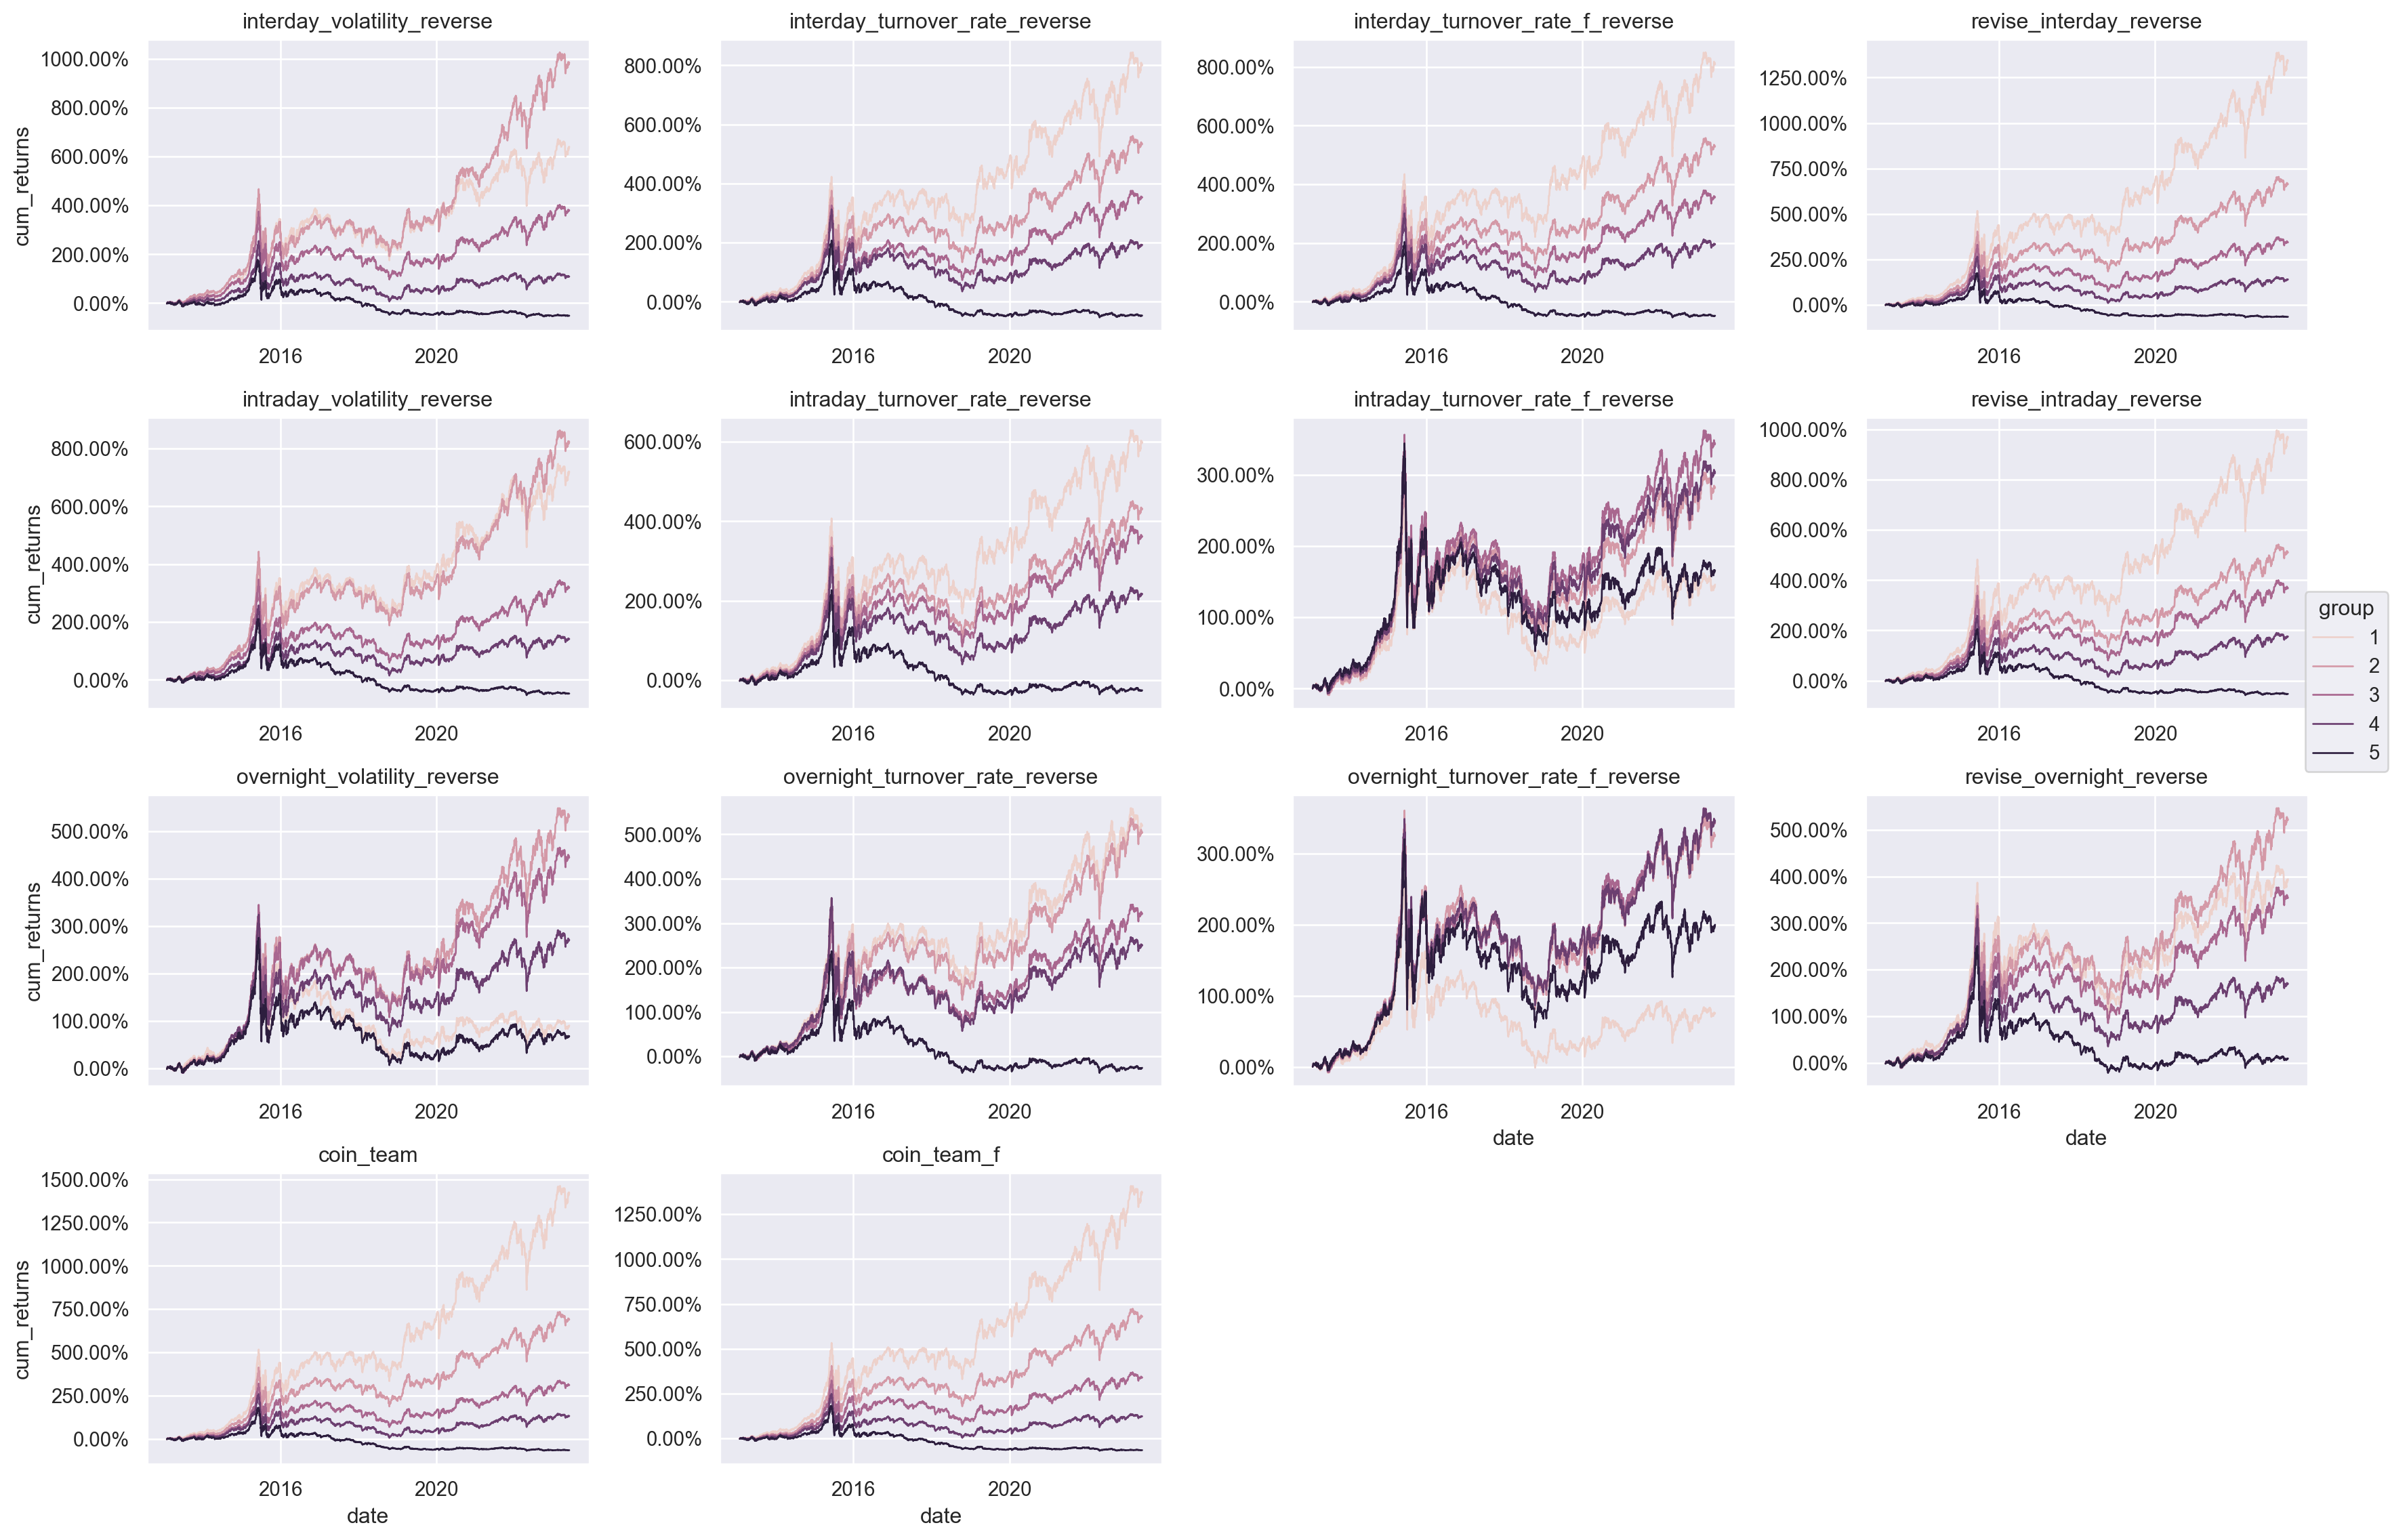

In [11]:
plot_cumulativeline_from_dataframe(group_cum)

# 使用Qlib进行检验

In [13]:
from qlib.data.dataset import DatasetH
from qlib.data.dataset.handler import DataHandlerLP
from src.plotting import model_performance_graph, report_graph
from src.qlib_workflow import QlibFlow
from src.utils import load2qlib

In [14]:
TARIN_PERIODS: Tuple = ("2014-01-01", "2017-12-31")
VALID_PERIODS: Tuple = ("2018-01-01", "2019-12-31")
TEST_PERIODS: Tuple = ("2020-01-01", "2023-02-17")

In [5]:
all_data:pd.DataFrame = pd.read_pickle('data/pkl/all_data.pkl')

In [61]:
all_data.head()

interday_volatility_reverse  \
datetime   instrument                                
2013-02-01 000001.SZ                      0.017790   
           000002.SZ                           NaN   
           000004.SZ                      0.007511   
           000005.SZ                      0.002562   
           000006.SZ                      0.006217   

                       interday_turnover_rate_reverse  \
datetime   instrument                                   
2013-02-01 000001.SZ                         0.018352   
           000002.SZ                              NaN   
           000004.SZ                         0.010310   
           000005.SZ                         0.008691   
           000006.SZ                         0.013543   

                       interday_turnover_rate_f_reverse  \
datetime   instrument                                     
2013-02-01 000001.SZ                           0.018352   
           000002.SZ                                NaN   
           000004.SZ                           0.010310   
           000005.SZ                           0.008691   
           000006.SZ                           0.018931   

                       revise_interday_reverse  intraday_volatility_reverse  \
datetime   instrument                                                         
2013-02-01 000001.SZ                  0.018071                     0.020224   
           000002.SZ                       NaN                          NaN   
           000004.SZ                  0.008910                     0.009922   
           000005.SZ                  0.005626                     0.005553   
           000006.SZ                  0.009880                     0.003828   

                       intraday_turnover_rate_reverse  \
datetime   instrument                                   
2013-02-01 000001.SZ                         0.017847   
           000002.SZ                              NaN   
           000004.SZ                         0.007618   
           000005.SZ                         0.005756   
           000006.SZ                         0.010930   

                       intraday_turnover_rate_f_reverse  \
datetime   instrument                                     
2013-02-01 000001.SZ                                NaN   
           000002.SZ                                NaN   
           000004.SZ                                NaN   
           000005.SZ                                NaN   
           000006.SZ                                NaN   

                       revise_intraday_reverse  overnight_volatility_reverse  \
datetime   instrument                                                          
2013-02-01 000001.SZ                  0.019035                      0.002373   
           000002.SZ                       NaN                           NaN   
           000004.SZ                  0.008770                      0.002368   
           000005.SZ                  0.005655                     -0.002932   
           000006.SZ                  0.007379                      0.002430   

                       overnight_turnover_rate_reverse  \
datetime   instrument                                    
2013-02-01 000001.SZ                          0.000559   
           000002.SZ                               NaN   
           000004.SZ                          0.002616   
           000005.SZ                          0.002912   
           000006.SZ                          0.002629   

                       overnight_turnover_rate_f_reverse  \
datetime   instrument                                      
2013-02-01 000001.SZ                                 NaN   
           000002.SZ                                 NaN   
           000004.SZ                                 NaN   
           000005.SZ                                 NaN   
           000006.SZ                                 NaN   

                       revise_overnight_reverse  coin_team  coin_team_f  

In [7]:
# 获取基础因子
sel_cols: List = [
    factor
    for factor in all_data.columns
    if (factor not in ["coin_team", "coin_team_f"]) and (factor.find("revise") == -1)
]

factor_base: pd.DataFrame = all_data[sel_cols].copy()

In [8]:
# 将pd.DataFrame转为DatasetH
ds:DatasetH = load2qlib(factor_base,TARIN_PERIODS,VALID_PERIODS,TEST_PERIODS)

[8784:MainThread](2023-07-18 16:00:08,635) INFO - qlib.timer - [log.py:128] - Time cost: 25.198s | Loading data Done
[8784:MainThread](2023-07-18 16:00:15,698) INFO - qlib.timer - [log.py:128] - Time cost: 6.977s | ProcessInf Done
[8784:MainThread](2023-07-18 16:00:52,104) INFO - qlib.timer - [log.py:128] - Time cost: 36.405s | CSRankNorm Done
[8784:MainThread](2023-07-18 16:00:52,818) INFO - qlib.timer - [log.py:128] - Time cost: 0.714s | Fillna Done
[8784:MainThread](2023-07-18 16:00:52,936) INFO - qlib.timer - [log.py:128] - Time cost: 0.117s | DropnaLabel Done
[8784:MainThread](2023-07-18 16:00:52,937) INFO - qlib.timer - [log.py:128] - Time cost: 44.302s | fit & process data Done
[8784:MainThread](2023-07-18 16:00:52,937) INFO - qlib.timer - [log.py:128] - Time cost: 69.500s | Init data Done


In [9]:
# 储存ds数据
ds.config(dump_all=True, recursive=True)
ds.to_pickle(path="data/pkl/dataset.pkl", dump_all=True)

In [8]:
# 储存dh_pr数据用于后续滚动训练
dh_pr: DataHandlerLP = load2qlib(
    factor_base, TARIN_PERIODS, VALID_PERIODS, TEST_PERIODS, output_type="DataHandlerLP"
)

dh_pr.to_pickle(path="data/pkl/data_dhpr.pkl", dump_all=True)

[23072:MainThread](2023-07-19 10:47:53,820) INFO - qlib.timer - [log.py:127] - Time cost: 24.657s | Loading data Done
[23072:MainThread](2023-07-19 10:48:00,040) INFO - qlib.timer - [log.py:127] - Time cost: 6.134s | ProcessInf Done
[23072:MainThread](2023-07-19 10:48:35,535) INFO - qlib.timer - [log.py:127] - Time cost: 35.495s | CSRankNorm Done
[23072:MainThread](2023-07-19 10:48:36,267) INFO - qlib.timer - [log.py:127] - Time cost: 0.730s | Fillna Done
[23072:MainThread](2023-07-19 10:48:36,385) INFO - qlib.timer - [log.py:127] - Time cost: 0.116s | DropnaLabel Done
[23072:MainThread](2023-07-19 10:48:36,385) INFO - qlib.timer - [log.py:127] - Time cost: 42.563s | fit & process data Done
[23072:MainThread](2023-07-19 10:48:36,386) INFO - qlib.timer - [log.py:127] - Time cost: 67.222s | Init data Done


## 球队硬币(coin-team factor)因子(Baseline)

以研报中的球队硬币因子为基线,时间范围选择2020年至2023-02-17,可以看到球队硬币因子有很好的单调性,低分组(因子值小)的收益最好

In [10]:
cointeam_pred_df: pd.DataFrame = all_data.loc[
    TEST_PERIODS[0] : TEST_PERIODS[1], ["coin_team", "next_ret"]
].rename(columns={"coin_team": "score", "next_ret": "label"})

d:\WorkSpace\QuantsPlaybook\B-因子构建类\个股动量效应的识别及球队硬币因子\src\plotting.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_label_drop["group"] = pred_label_drop.groupby(level="datetime")[
d:\WorkSpace\QuantsPlaybook\B-因子构建类\个股动量效应的识别及球队硬币因子\src\plotting.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_label_drop.loc[:,"group"] = pred_label_drop["group"].apply(lambda x: "Group%d" % x)


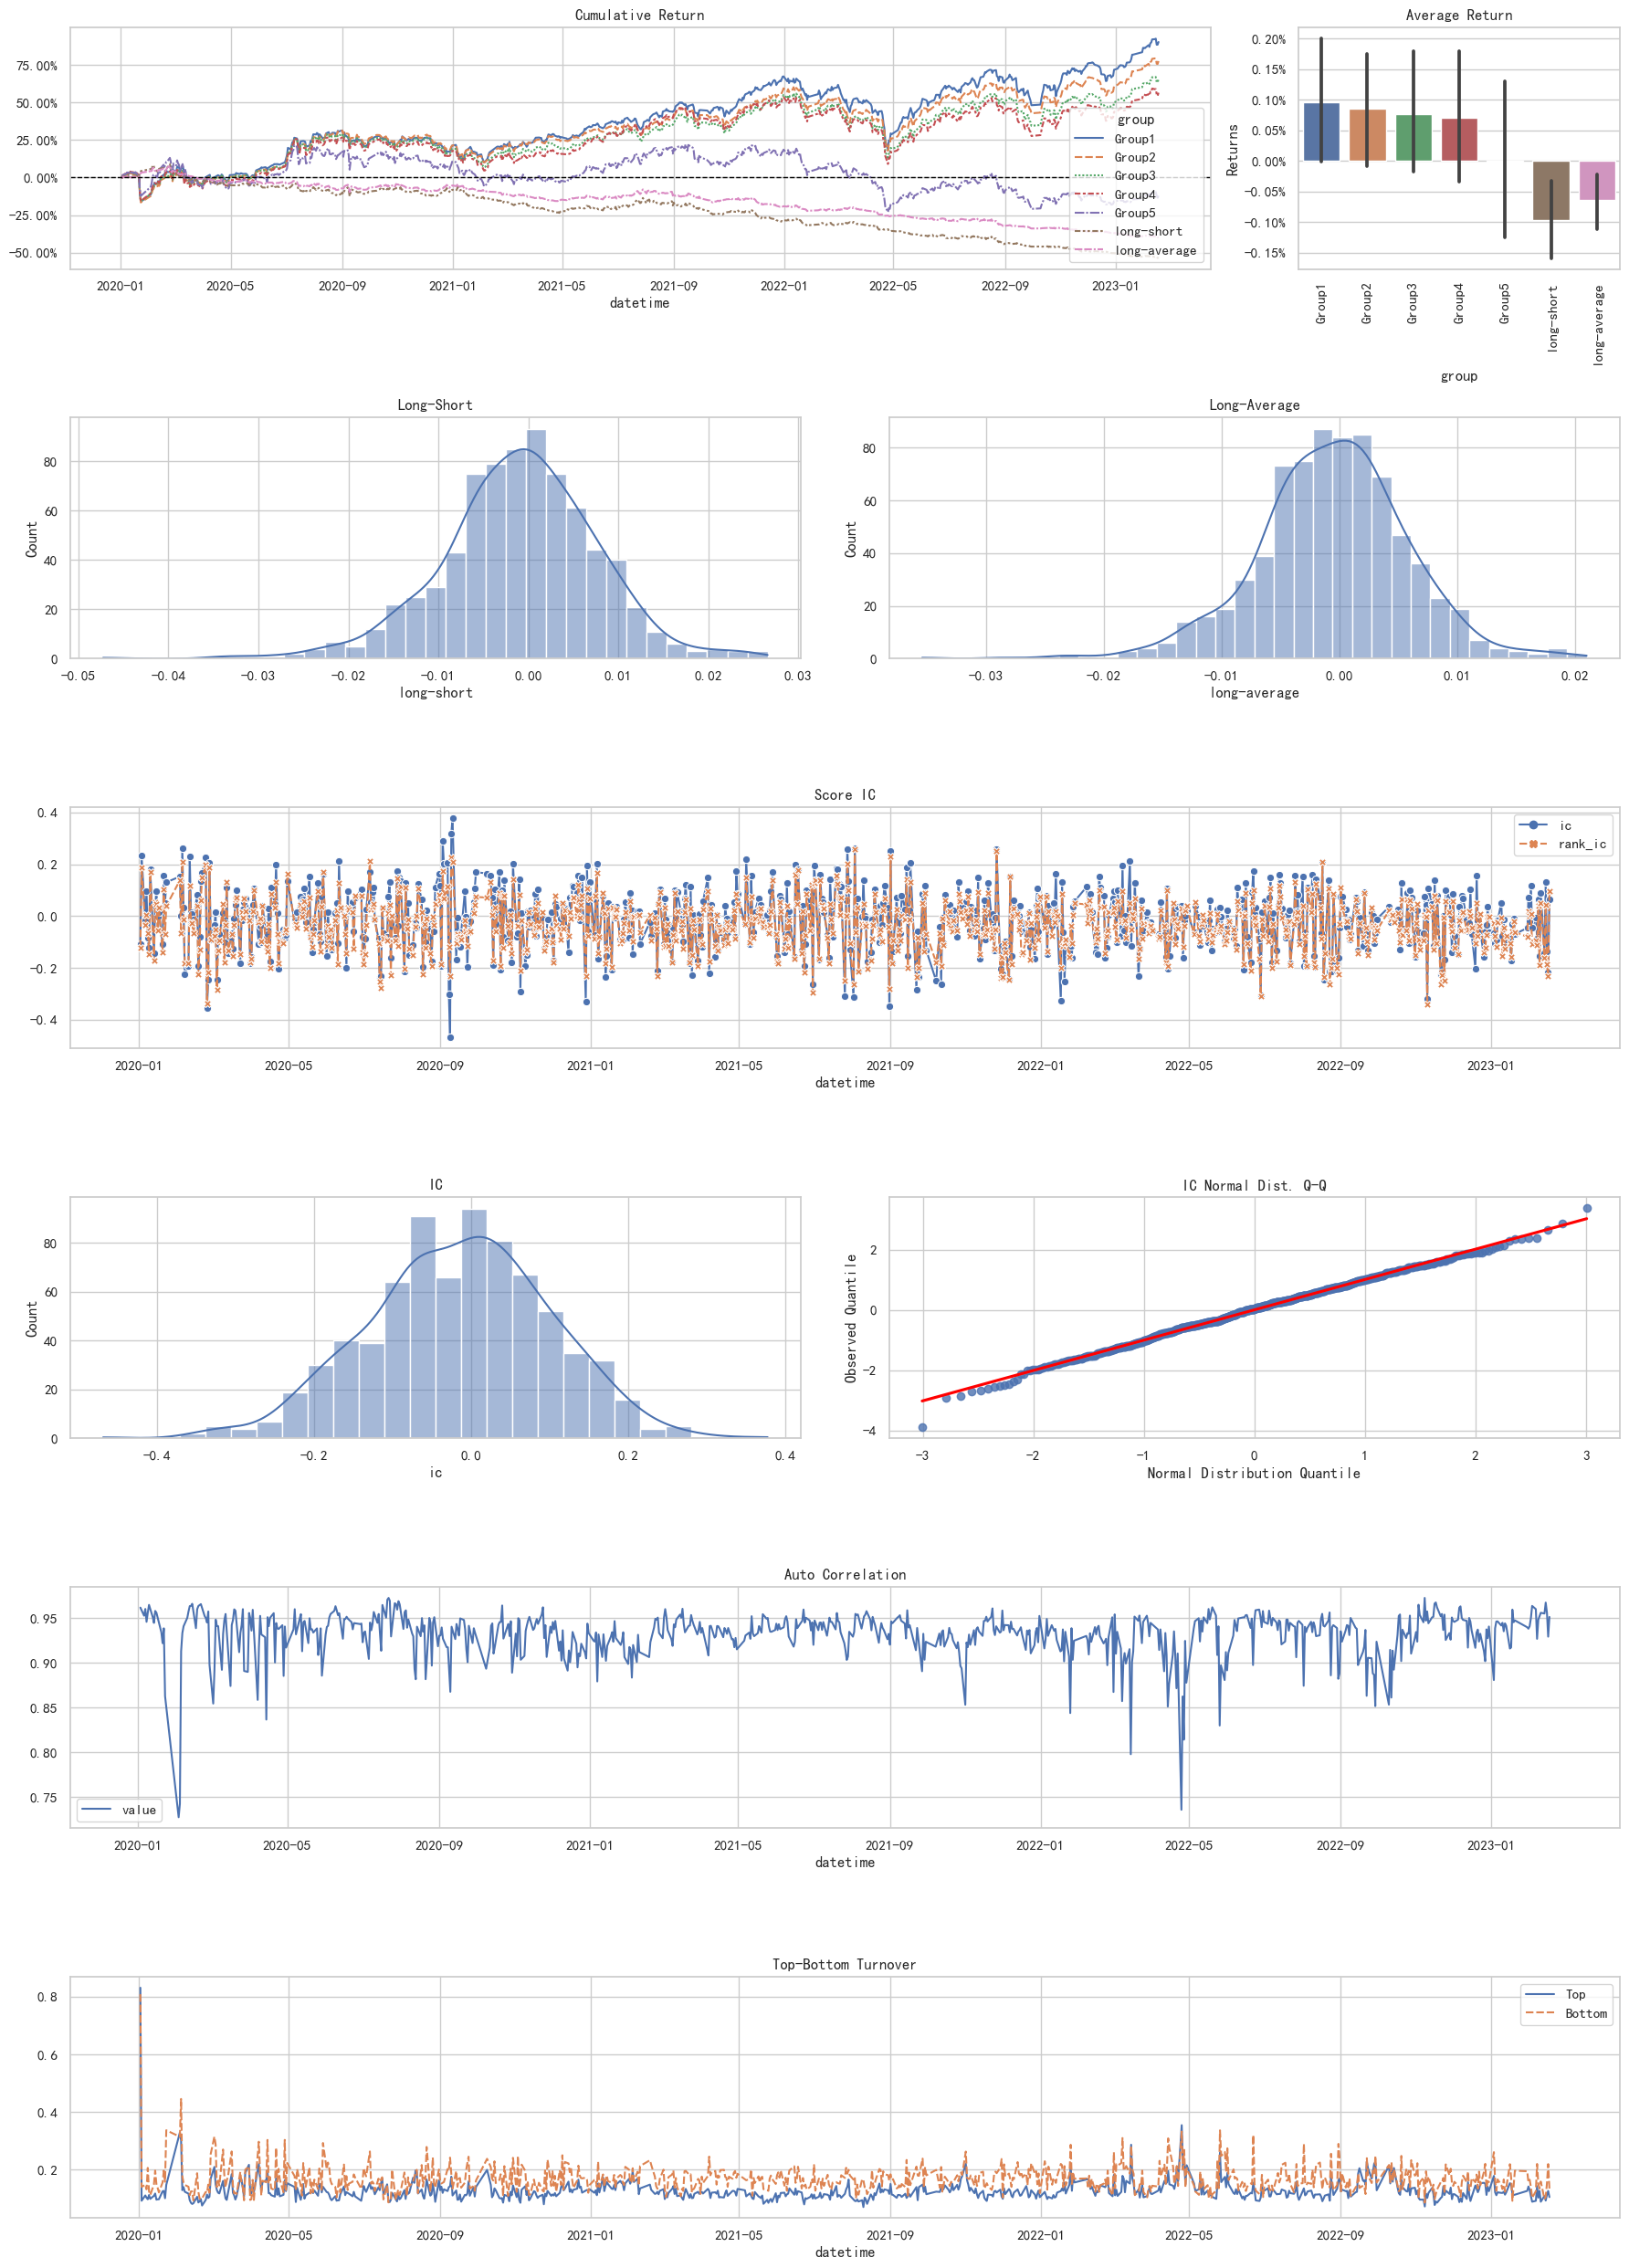

In [11]:
performance_graph = model_performance_graph(cointeam_pred_df)

In [24]:
# 使用
baseline_model = QlibFlow(
    dataset=ds, model="gbdt", start_time=TEST_PERIODS[0], end_time=TEST_PERIODS[1]
)

这里对球队硬币因子进行回测,虽然初始化了数据,但最终使用backtest方法时仅使用球队硬币因子值进行回测,回测默认使用**因子值最大**的topk只股票构建组合,所以这里我们将因子值乘-1反转因子值。

In [28]:
coin_team:pd.DataFrame = all_data['coin_team_f'].to_frame('score')
baseline_model.backtest(pred_score=coin_team*-1,topk=50)

[32992:MainThread](2023-07-12 10:42:04,402) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x000001CAD43B6880>
[32992:MainThread](2023-07-12 10:42:04,405) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[32992:MainThread](2023-07-12 10:42:22,744) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[32992:MainThread](2023-07-12 10:42:22,747) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.


backtest loop:   0%|          | 0/757 [00:00<?, ?it/s]

In [29]:
coin_team_1day_df: pd.DataFrame = baseline_model.portfolio_metric_dict['1day'][0]

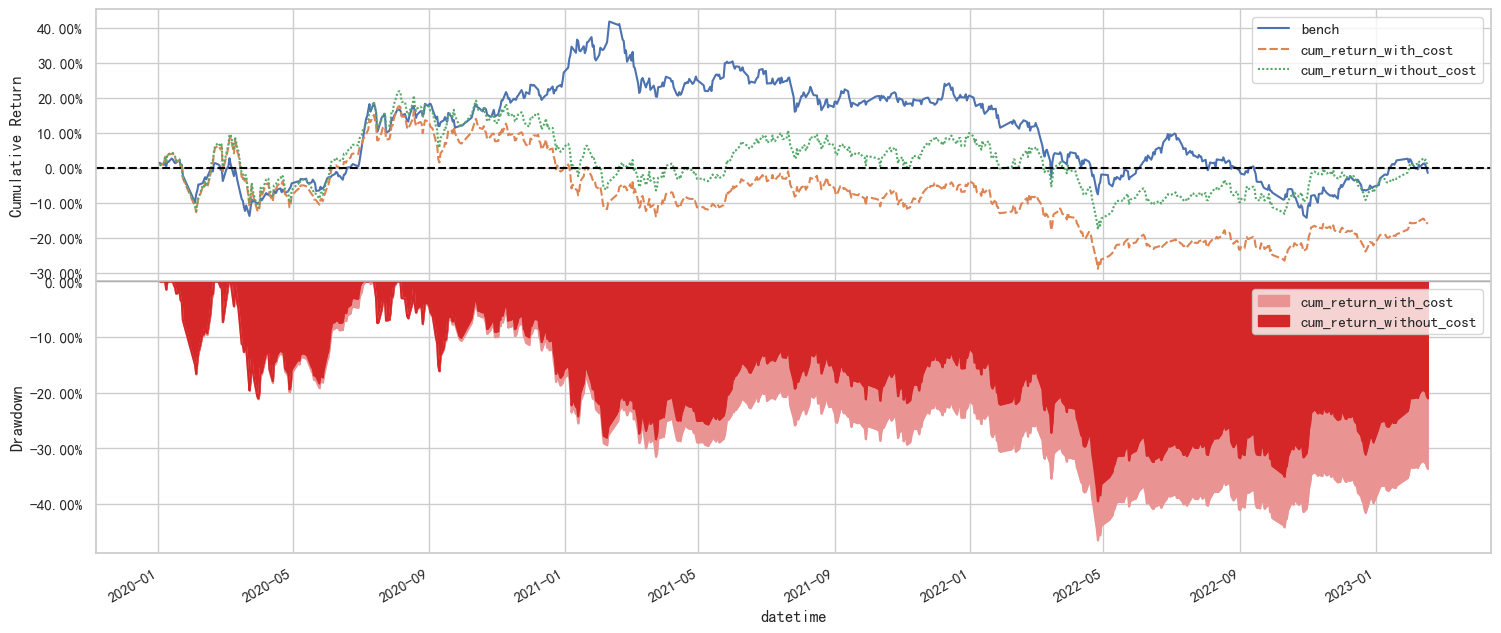

In [30]:
coin_team_return_fig = report_graph(coin_team_1day_df)

## LGBMRanker模型

In [31]:
lgbmrank_model = QlibFlow(
    dataset=ds,
    model="ranker",
    start_time=TEST_PERIODS[0],
    end_time=TEST_PERIODS[1],
    model_kw={"eval_at": [5]},
)

In [32]:
lgbmrank_model.fit('rk_train') # 
lgbmrank_model.predict('rk_predict')
lgbmrank_model.backtest(topk=50)

[32992:MainThread](2023-07-12 10:43:10,261) INFO - qlib.workflow - [exp.py:258] - Experiment 3 starts running ...


[32992:MainThread](2023-07-12 10:43:10,357) INFO - qlib.workflow - [recorder.py:341] - Recorder b1d4ccf01fcc41c9848012706361322b starts running under Experiment 3 ...
d:\anaconda3\envs\qlib_env\lib\site-packages\lightgbm\engine.py:177: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] eval_at is set=5, ndcg_eval_at=5 will be ignored. Current value: eval_at=5
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] eval_at is set=5, ndcg_eval_at=5 will be ignored. Current value: eval_at=5
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2792322, number of used features: 9
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4090, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (31.96 MB) transferred to GPU in 0.019207 secs. 0 sparse feature groups
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] eval_at is set=5, ndcg_eval_at=5 will be ignored. Current value: eval_at=5
[LightGBM] [Info] Start training from score

train info

{
    'class': 'Recorder',
    'id': 'b1d4ccf01fcc41c9848012706361322b',
    'name': 'mlflow_recorder',
    'experiment_id': '3',
    'start_time': '2023-07-12 10:43:10',
    'end_time': None,
    'status': 'RUNNING'
}

...

predict info

{
    'class': 'Recorder',
    'id': 'e7851ce3fd48483ca999d05162dbf72b',
    'name': 'mlflow_recorder',
    'experiment_id': '4',
    'start_time': '2023-07-12 10:43:16',
    'end_time': None,
    'status': 'RUNNING'
}

[32992:MainThread](2023-07-12 10:43:18,370) INFO - qlib.timer - [log.py:128] - Time cost: 0.001s | waiting `async_log` Done
[32992:MainThread](2023-07-12 10:43:18,847) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x000001CB34CC06A0>
[32992:MainThread](2023-07-12 10:43:18,852) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[32992:MainThread](2023-07-12 10:43:37,323) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[32992:MainThread](2023-07-12 10:43:37,324) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.


backtest loop:   0%|          | 0/757 [00:00<?, ?it/s]

d:\anaconda3\envs\qlib_env\lib\site-packages\qlib\utils\index_data.py:482: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)


In [33]:
pred_label_df: pd.DataFrame = lgbmrank_model.get_pred(experiment_name="rk_predict",recorder_id='e7851ce3fd48483ca999d05162dbf72b')
pred_label_df.tail()

label     score
datetime   instrument                    
2023-02-17 688799.SH  -0.014541  2.060226
           688800.SH  -0.021903  1.914786
           688819.SH   0.004603  2.045630
           688981.SH   0.006908  2.011794
           689009.SH   0.019512  2.025651

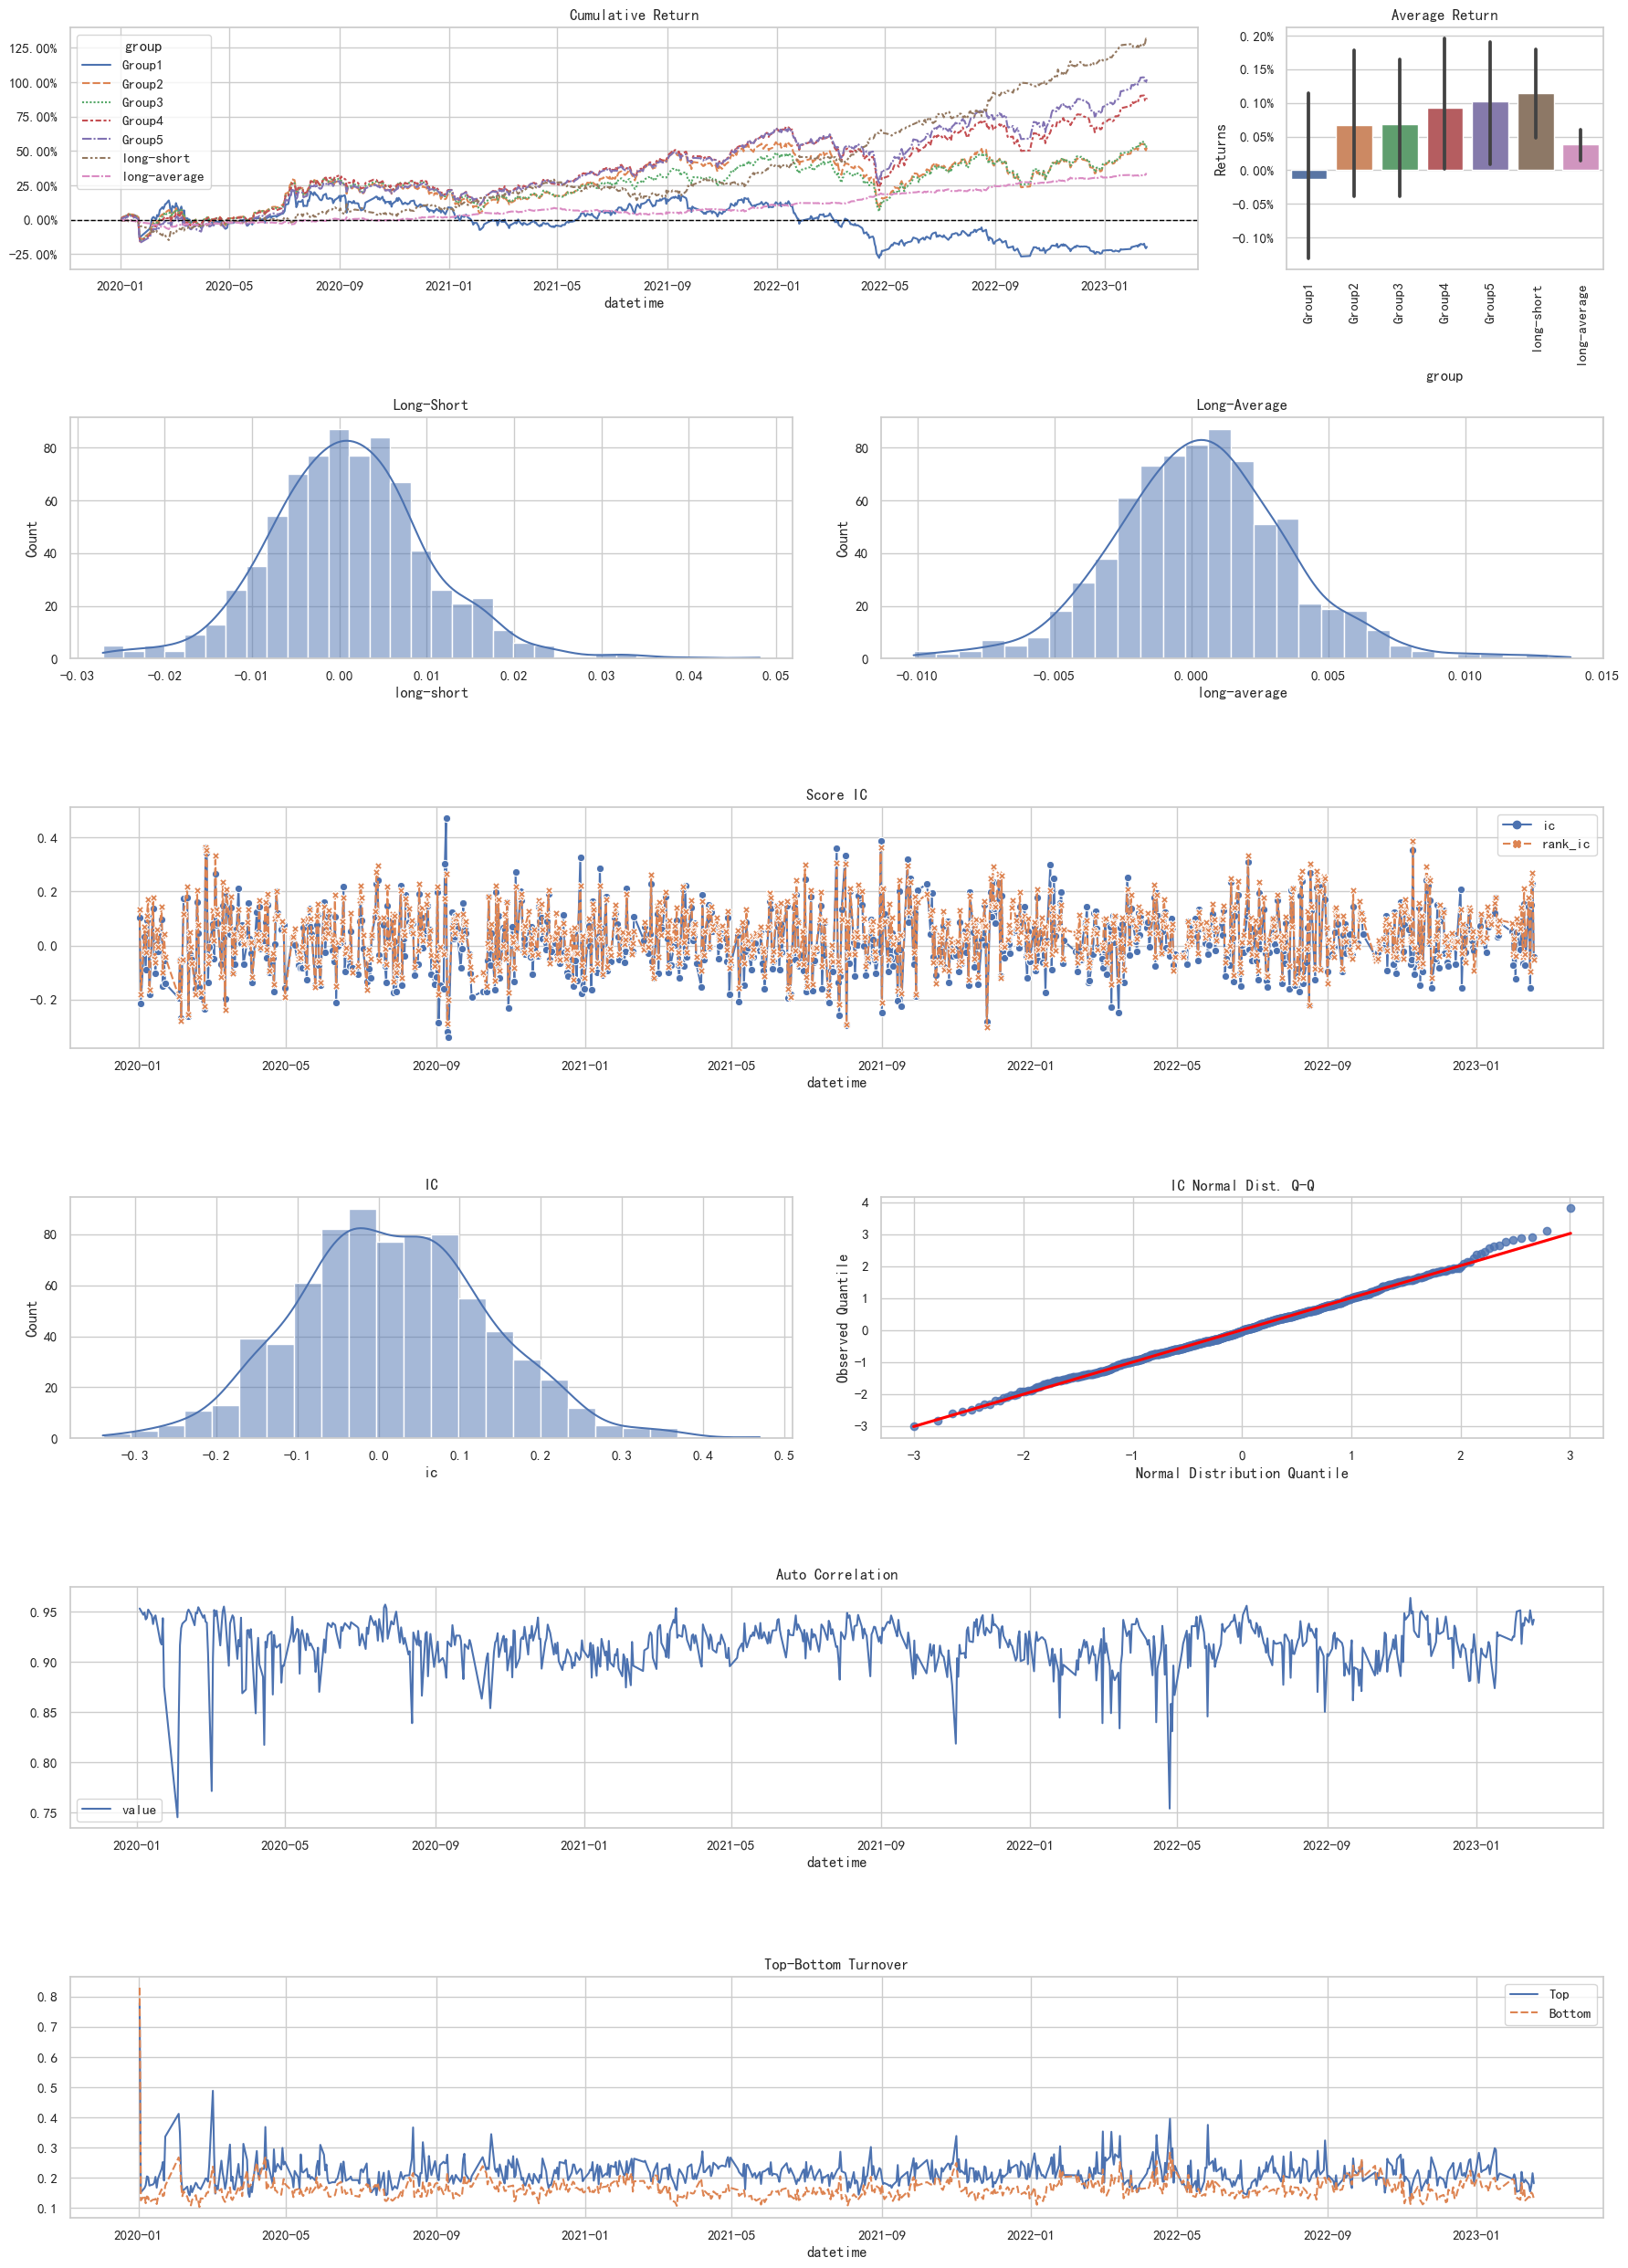

In [34]:
performance_graph = model_performance_graph(pred_label_df)

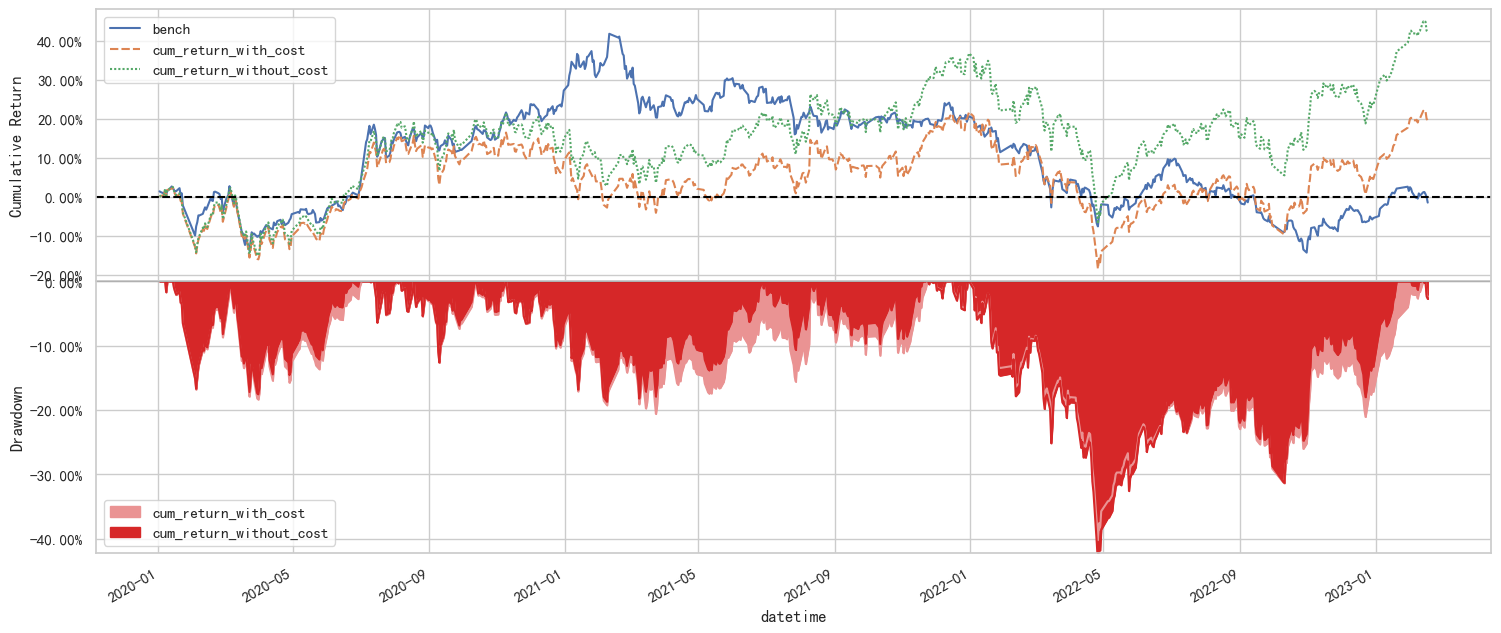

In [36]:
rk_fig = report_graph(lgbmrank_model.portfolio_metric_dict['1day'][0])

## LGBM模型复合因子

In [37]:
gdbt_model = QlibFlow(
    dataset=ds, model="gbdt", start_time=TEST_PERIODS[0], end_time=TEST_PERIODS[1]
)

In [38]:
gdbt_model.fit('train')
gdbt_model.predict('predict')
gdbt_model.backtest(topk=50)

[32992:MainThread](2023-07-12 10:45:27,072) INFO - qlib.workflow - [exp.py:258] - Experiment 5 starts running ...
[32992:MainThread](2023-07-12 10:45:27,089) INFO - qlib.workflow - [recorder.py:341] - Recorder 2c2b0a19d83a4c90804307dbd367c83a starts running under Experiment 5 ...


Training until validation scores don't improve for 200 rounds
[20]	train's l2: 0.897057	valid's l2: 0.96822
[40]	train's l2: 0.896396	valid's l2: 0.967702
[60]	train's l2: 0.896032	valid's l2: 0.96754
[80]	train's l2: 0.895742	valid's l2: 0.967479
[100]	train's l2: 0.895496	valid's l2: 0.967462
[120]	train's l2: 0.895261	valid's l2: 0.967468
[140]	train's l2: 0.895036	valid's l2: 0.967482
[160]	train's l2: 0.894822	valid's l2: 0.9675
[180]	train's l2: 0.894622	valid's l2: 0.96752
[200]	train's l2: 0.894426	valid's l2: 0.967545
[220]	train's l2: 0.894232	valid's l2: 0.967565
[240]	train's l2: 0.894046	valid's l2: 0.967587
[260]	train's l2: 0.893867	valid's l2: 0.967613
[280]	train's l2: 0.893693	valid's l2: 0.967633
[300]	train's l2: 0.893522	valid's l2: 0.967652
Early stopping, best iteration is:
[103]	train's l2: 0.895463	valid's l2: 0.967461


train info

{
    'class': 'Recorder',
    'id': '2c2b0a19d83a4c90804307dbd367c83a',
    'name': 'mlflow_recorder',
    'experiment_id': '5',
    'start_time': '2023-07-12 10:45:27',
    'end_time': None,
    'status': 'RUNNING'
}

[32992:MainThread](2023-07-12 10:45:40,419) INFO - qlib.timer - [log.py:128] - Time cost: 0.448s | waiting `async_log` Done
[32992:MainThread](2023-07-12 10:45:40,422) INFO - qlib.workflow - [exp.py:258] - Experiment 6 starts running ...
[32992:MainThread](2023-07-12 10:45:40,442) INFO - qlib.workflow - [recorder.py:341] - Recorder f2968244299e4bca8ff80c619979a63b starts running under Experiment 6 ...
[32992:MainThread](2023-07-12 10:45:42,616) INFO - qlib.workflow - [record_temp.py:196] - Signal record 'pred.pkl' has been saved as the artifact of the Experiment 6


...

predict info

{
    'class': 'Recorder',
    'id': 'f2968244299e4bca8ff80c619979a63b',
    'name': 'mlflow_recorder',
    'experiment_id': '6',
    'start_time': '2023-07-12 10:45:40',
    'end_time': None,
    'status': 'RUNNING'
}

[32992:MainThread](2023-07-12 10:45:44,119) INFO - qlib.timer - [log.py:128] - Time cost: 0.000s | waiting `async_log` Done
[32992:MainThread](2023-07-12 10:45:45,978) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x000001CAD4AE5BB0>
[32992:MainThread](2023-07-12 10:45:45,984) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[32992:MainThread](2023-07-12 10:46:04,269) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[32992:MainThread](2023-07-12 10:46:04,271) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.


backtest loop:   0%|          | 0/757 [00:00<?, ?it/s]

d:\anaconda3\envs\qlib_env\lib\site-packages\qlib\utils\index_data.py:482: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)


In [39]:
pred_label_df: pd.DataFrame = gdbt_model.get_pred(experiment_name="predict")
pred_label_df.tail()

[32992:MainThread](2023-07-12 10:46:12,888) WARNING - qlib.workflow - [exp.py:308] - Please make sure the recorder name mlflow_recorder is unique, we will only return the latest recorder if there exist several matched the given name.


label     score
datetime   instrument                    
2023-02-17 688799.SH  -0.014541  0.052007
           688800.SH  -0.021903 -0.075911
           688819.SH   0.004603  0.043572
           688981.SH   0.006908  0.012611
           689009.SH   0.019512  0.020896

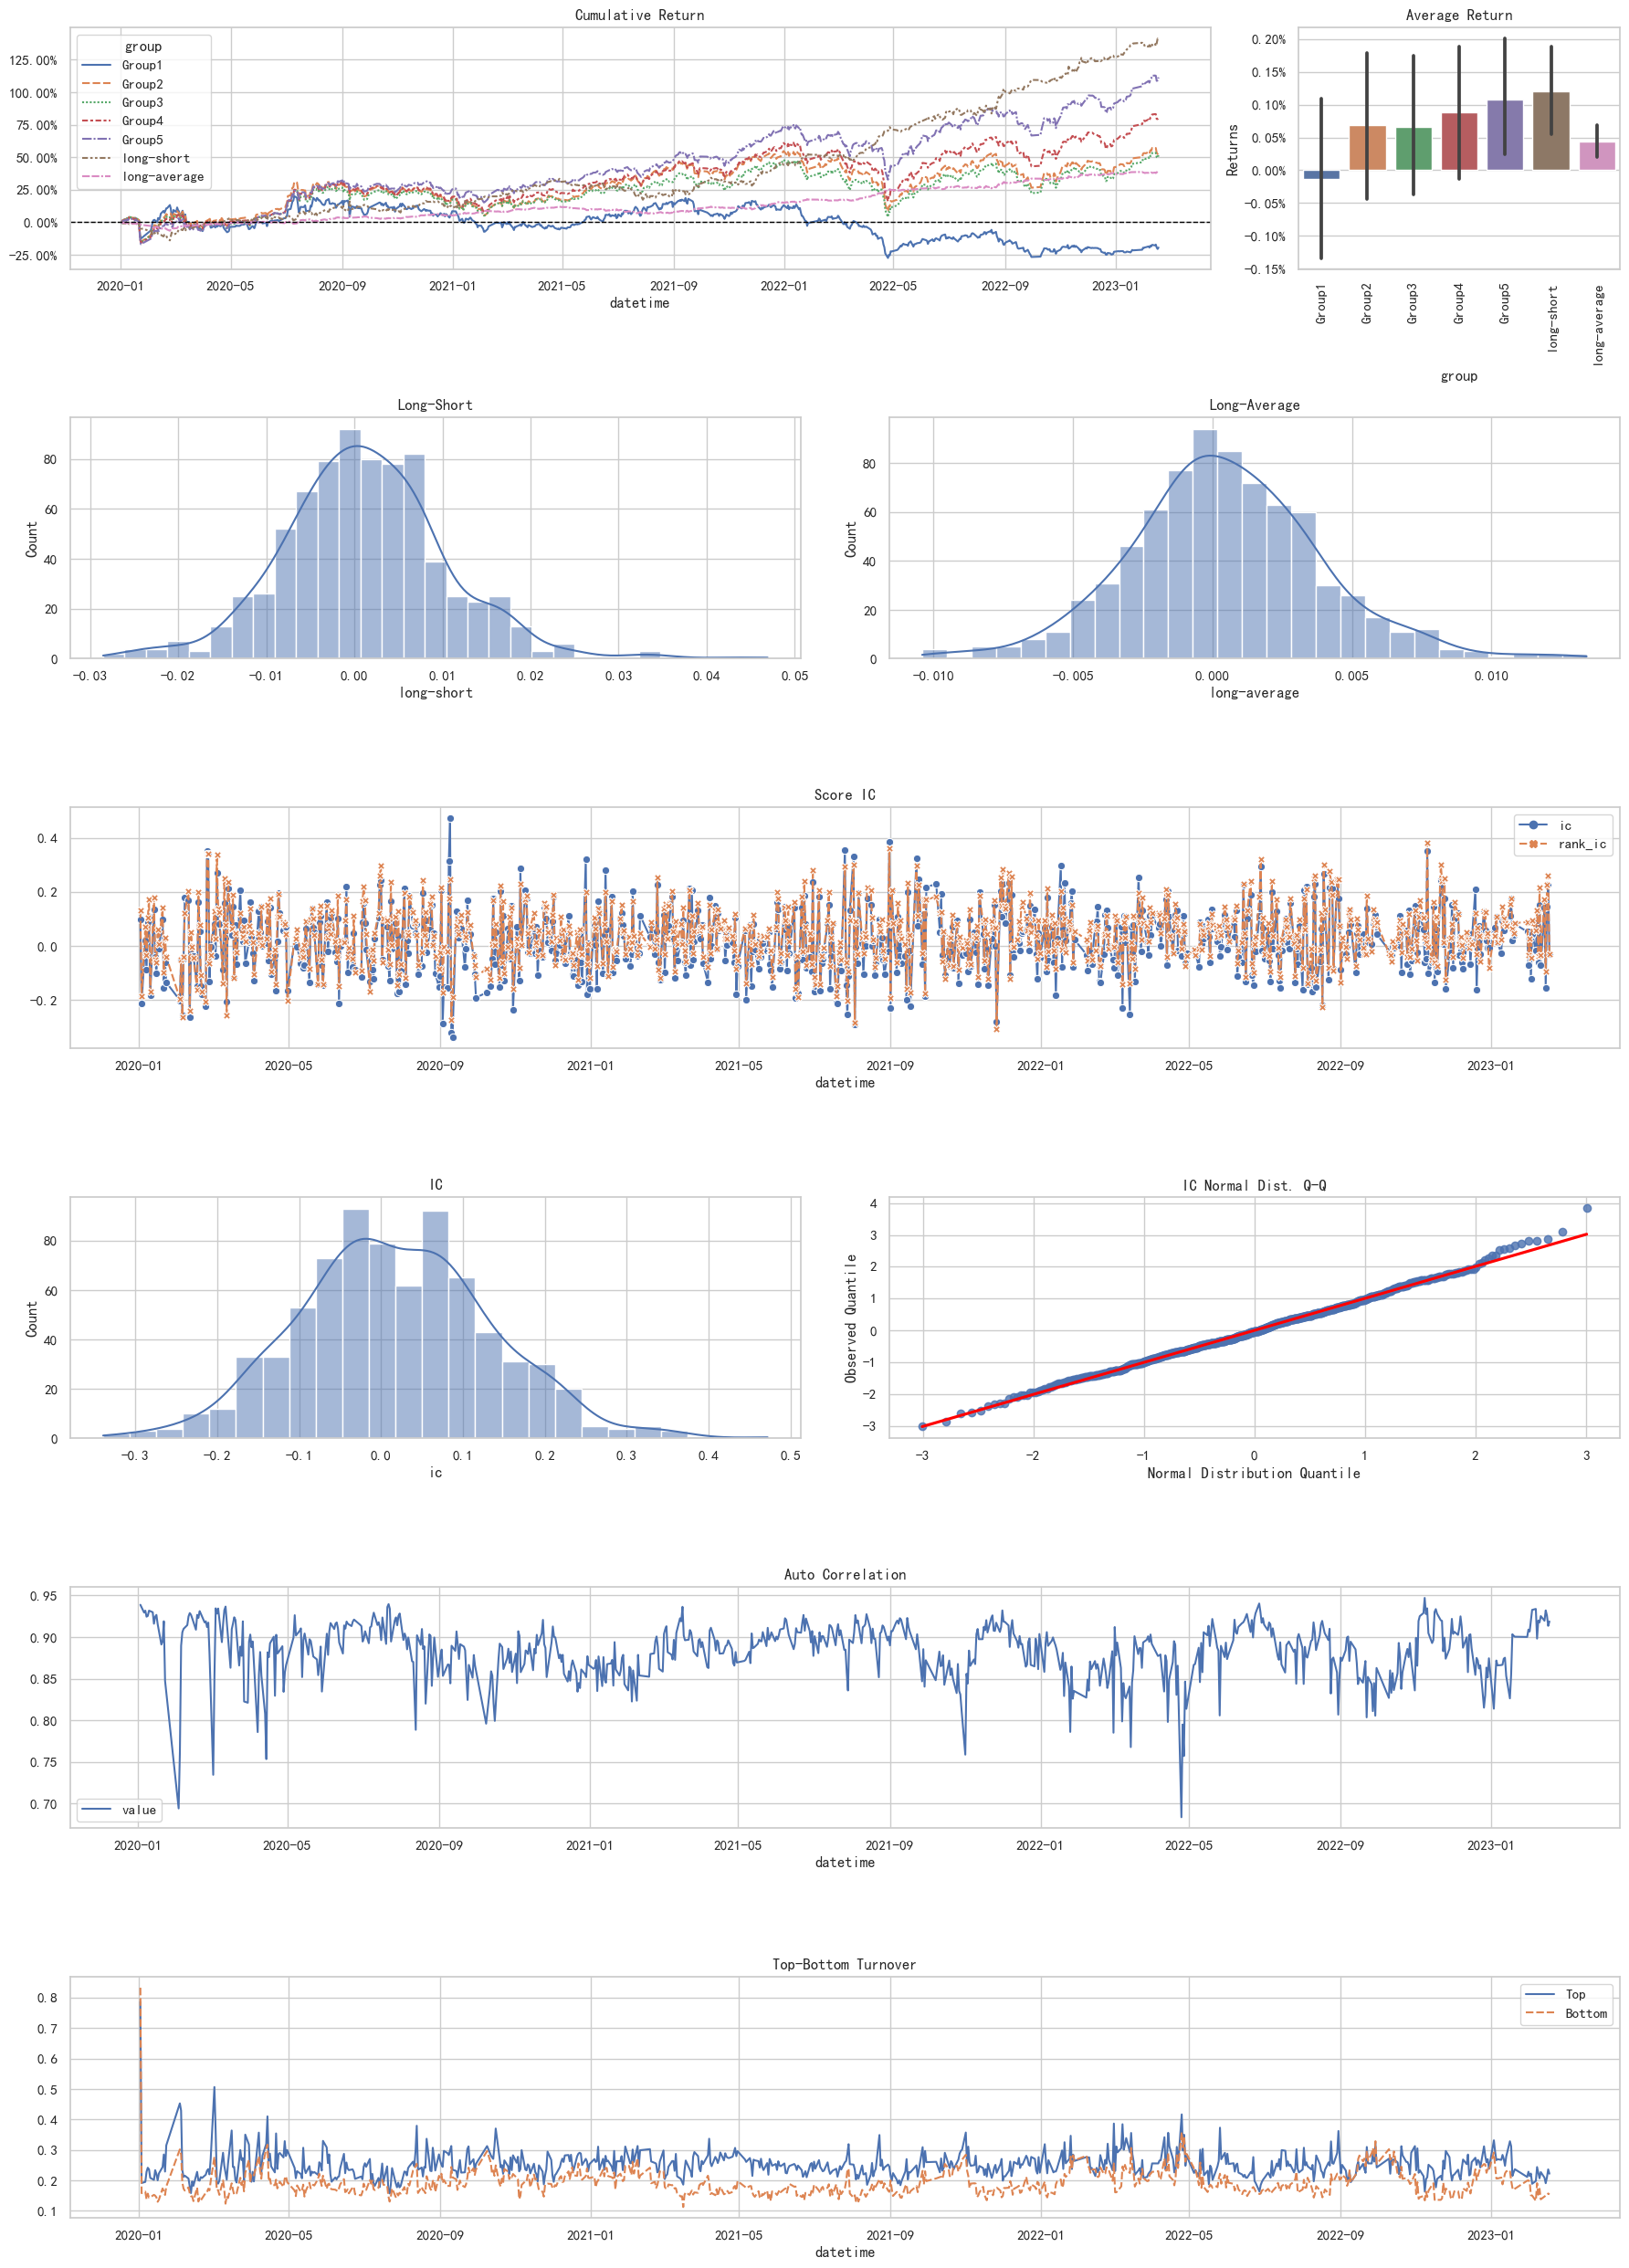

In [40]:
performance_graph = model_performance_graph(pred_label_df)

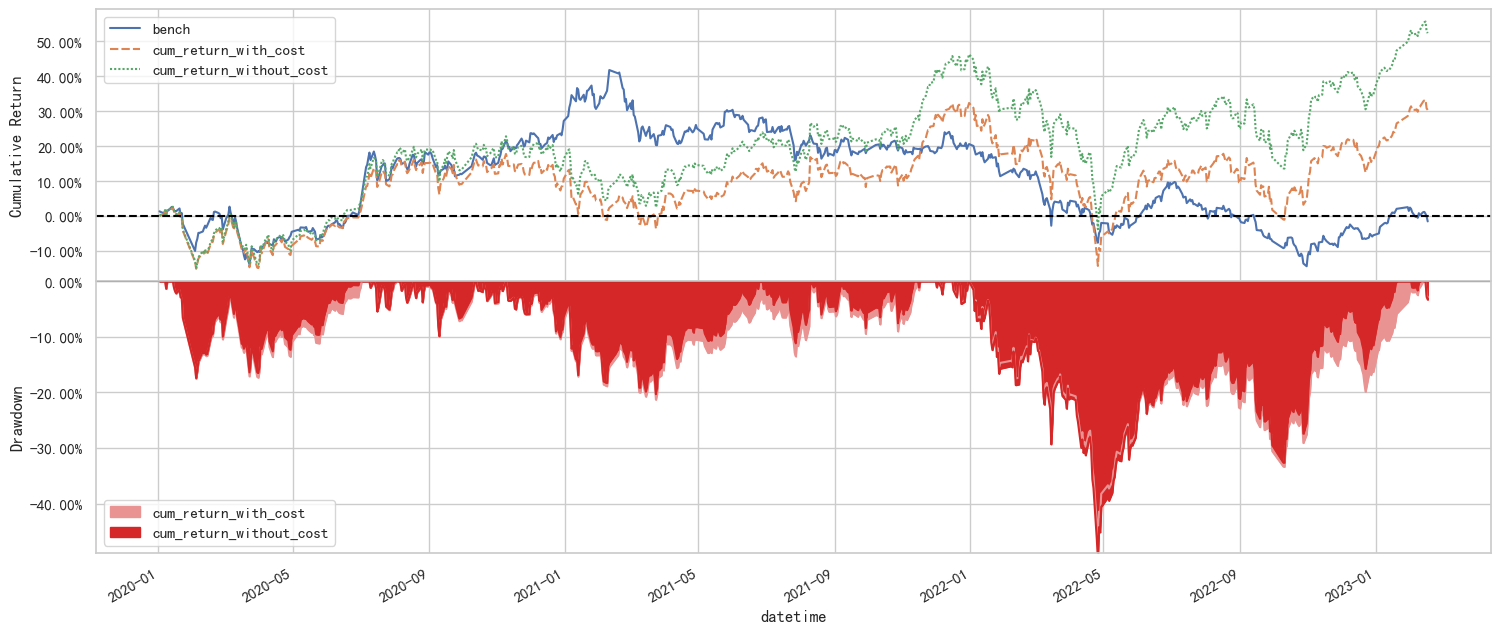

In [41]:
fig = report_graph(gdbt_model.portfolio_metric_dict['1day'][0])

## 对比

In [43]:
from typing import Dict

In [44]:
ranker_ic_dict: Dict = lgbmrank_model.R.get_recorder(
    experiment_name="rk_v_predict", recorder_id="e7851ce3fd48483ca999d05162dbf72b"
).list_metrics()
gdbt_ic_dict: Dict = gdbt_model.R.get_recorder(
    experiment_name="predict", recorder_id="f2968244299e4bca8ff80c619979a63b"
).list_metrics()

In [45]:
ic_df: pd.DataFrame = pd.concat(
    (pd.Series(ranker_ic_dict), pd.Series(gdbt_ic_dict)), axis=1
)
ic_df.columns = ["ranker", "gdbt"]

In [46]:
ic_df

,ranker,gdbt
IC,0.017389,0.017585
ICIR,0.146436,0.148736
Rank IC,0.043749,0.042594
Rank ICIR,0.395270,0.392538


# 日间/日内低波动率反转因子

## LGBMRanker模型

In [33]:
volatility_momentum: pd.DataFrame = get_factor_data_and_forward_return(
    VolatilityMomentum,
    window=20,
    periods=1,
    factor_names=["interday_volatility_reverse", "intraday_volatility_reverse"],
)

2023-07-11 16:31:43.433 | INFO     | src.build_factor:get_factor_data_and_forward_return:189 - start get base data...
2023-07-11 16:32:01.268 | INFO     | src.build_factor:get_factor_data_and_forward_return:192 - base data success!
2023-07-11 16:32:01.269 | INFO     | src.build_factor:get_factor_data_and_forward_return:194 - start get next return data...
2023-07-11 16:32:19.824 | INFO     | src.build_factor:get_factor_data_and_forward_return:198 - next return data success!
2023-07-11 16:32:19.824 | INFO     | src.build_factor:get_factor_data_and_forward_return:199 - start get factor data...
[Parallel(n_jobs=-1)]: Using backend MultiprocessingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   11.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   11.3s finished
2023-07-11 16:33:01.039 | INFO     | src.build_factor:get_factor_data_and_forward_return:204 - factor data success!
2023-07-11 16:33:01.040 | INFO     | src.build

In [34]:
volatility_momentum.tail()

interday_lowvolatility_momentum  \
datetime   instrument                                    
2023-05-29 688799.SH                         -0.000697   
           688800.SH                               NaN   
           688819.SH                         -0.004090   
           688981.SH                               NaN   
           689009.SH                          0.003161   

                       intraday_lowvolatility_momentum  next_ret  
datetime   instrument                                             
2023-05-29 688799.SH                         -0.000331 -0.016457  
           688800.SH                               NaN  0.009245  
           688819.SH                         -0.000683 -0.001422  
           688981.SH                               NaN  0.009772  
           689009.SH                          0.001576  0.026918

In [35]:
# 储存数据
volatility_momentum.to_pickle('data/pkl/volatility_momentum.pkl')

In [36]:
volatility_momentum: pd.DataFrame = pd.read_pickle("data/pkl/volatility_momentum.pkl")

In [37]:
clean_factor_res = get_factor_group_returns(volatility_momentum,quantiles=5,max_loss=0.48)

【Interday_Lowvolatility_Momentum】:Dropped 47.0% entries from factor data: 47.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
【Interday_Lowvolatility_Momentum】:max_loss is 48.0%, not exceeded: OK!
【Intraday_Lowvolatility_Momentum】:Dropped 47.3% entries from factor data: 47.3% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
【Intraday_Lowvolatility_Momentum】:max_loss is 48.0%, not exceeded: OK!


In [38]:
group_cum: pd.DataFrame = clean_factor_res.factor_return.groupby(
    level=0, axis=1, group_keys=False
).apply(ep.cum_returns)

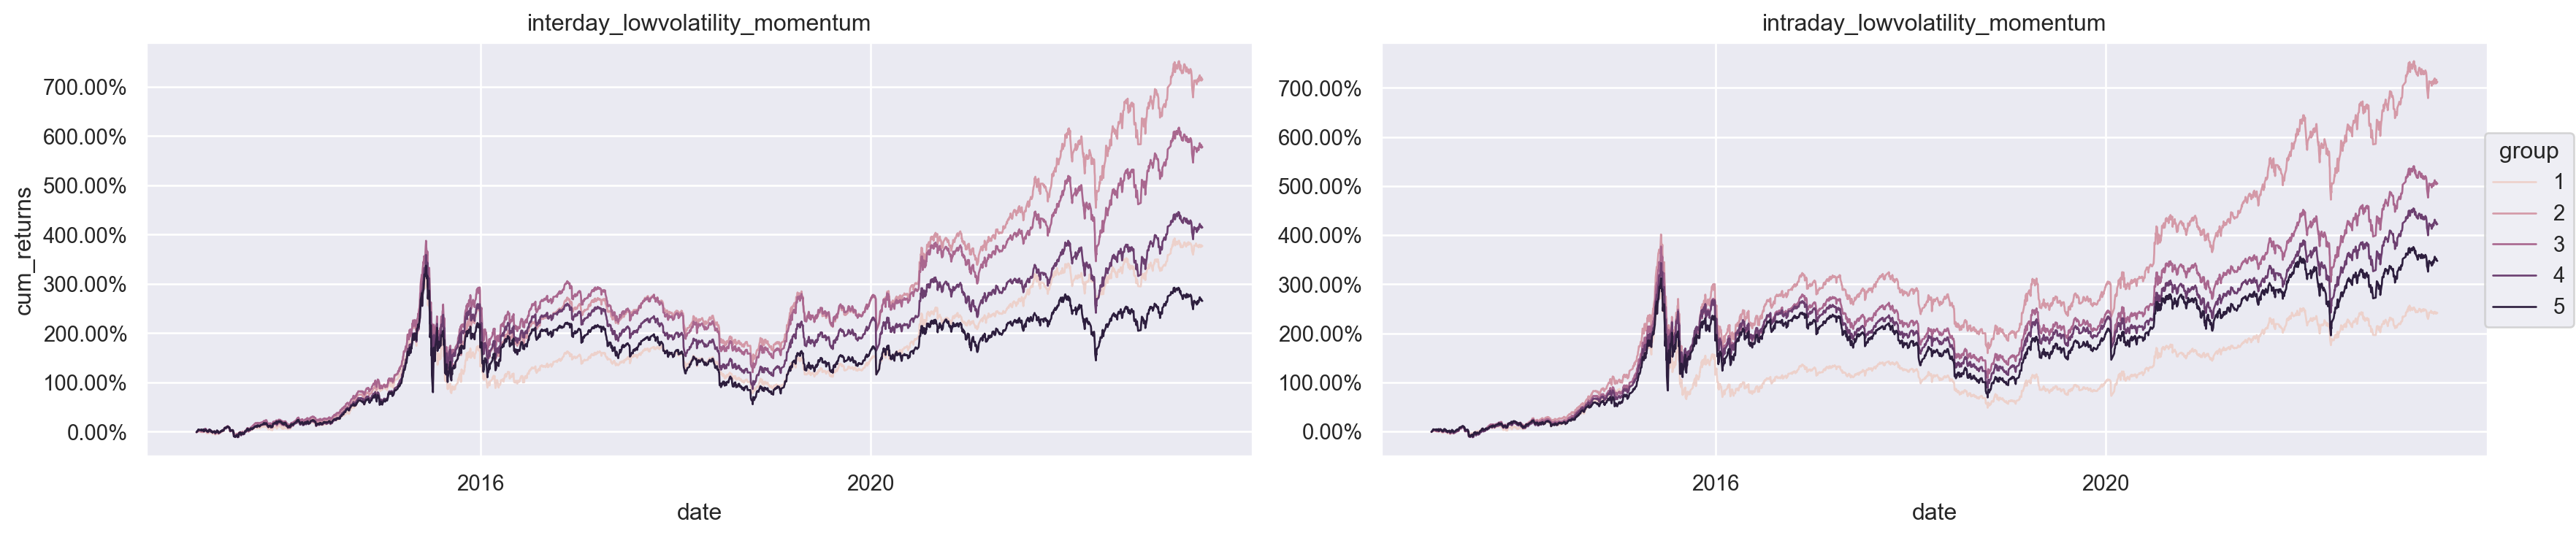

In [39]:
plot_cumulativeline_from_dataframe(group_cum,figsize=(18,4))

In [40]:
# 将pd.DataFrame转为DatasetH
ds:DatasetH = load2qlib(volatility_momentum,TARIN_PERIODS,VALID_PERIODS,TEST_PERIODS)

[9024:MainThread](2023-07-11 16:34:17,435) INFO - qlib.timer - [log.py:128] - Time cost: 24.769s | Loading data Done
[9024:MainThread](2023-07-11 16:34:22,570) INFO - qlib.timer - [log.py:128] - Time cost: 5.111s | ProcessInf Done
[9024:MainThread](2023-07-11 16:34:30,558) INFO - qlib.timer - [log.py:128] - Time cost: 7.986s | CSRankNorm Done
[9024:MainThread](2023-07-11 16:34:30,778) INFO - qlib.timer - [log.py:128] - Time cost: 0.220s | Fillna Done
[9024:MainThread](2023-07-11 16:34:30,835) INFO - qlib.timer - [log.py:128] - Time cost: 0.055s | DropnaLabel Done
[9024:MainThread](2023-07-11 16:34:30,836) INFO - qlib.timer - [log.py:128] - Time cost: 13.400s | fit & process data Done
[9024:MainThread](2023-07-11 16:34:30,837) INFO - qlib.timer - [log.py:128] - Time cost: 38.170s | Init data Done


In [41]:
lgbmrank_v_model = QlibFlow(
    dataset=ds, model="ranker", start_time=TEST_PERIODS[0], end_time=TEST_PERIODS[1],model_kw={"eval_at":[3]}
)

In [42]:
lgbmrank_v_model.fit('rk_v_train')
lgbmrank_v_model.predict('rk_v_predict')
lgbmrank_v_model.backtest()

[9024:MainThread](2023-07-11 16:34:30,892) INFO - qlib.workflow - [exp.py:258] - Experiment 1 starts running ...
[9024:MainThread](2023-07-11 16:34:30,908) INFO - qlib.workflow - [recorder.py:341] - Recorder e98e25955a8f47a68ea3792879cf8ca0 starts running under Experiment 1 ...
d:\anaconda3\envs\qlib_env\lib\site-packages\lightgbm\engine.py:177: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] eval_at is set=3, ndcg_eval_at=5 will be ignored. Current value: eval_at=3
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] eval_at is set=3, ndcg_eval_at=5 will be ignored. Current value: eval_at=3
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 2792322, number of used features: 2
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4090, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 2 dense feature groups (10.65 MB) transferred to GPU in 0.005738 secs. 0 sparse feature groups
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] eval_at is set=3, ndcg_eval_at=5 will be ignored. Current value: eval_at=3
[LightGBM] [Info] Start training from score 

train info

{
    'class': 'Recorder',
    'id': 'e98e25955a8f47a68ea3792879cf8ca0',
    'name': 'mlflow_recorder',
    'experiment_id': '1',
    'start_time': '2023-07-11 16:34:30',
    'end_time': None,
    'status': 'RUNNING'
}

[9024:MainThread](2023-07-11 16:34:34,672) INFO - qlib.timer - [log.py:128] - Time cost: 0.001s | waiting `async_log` Done
[9024:MainThread](2023-07-11 16:34:34,679) INFO - qlib.workflow - [exp.py:258] - Experiment 2 starts running ...
[9024:MainThread](2023-07-11 16:34:34,703) INFO - qlib.workflow - [recorder.py:341] - Recorder 6eeae73a03b64abe90bb2c533cbac1b3 starts running under Experiment 2 ...
[9024:MainThread](2023-07-11 16:34:35,138) INFO - qlib.workflow - [record_temp.py:196] - Signal record 'pred.pkl' has been saved as the artifact of the Experiment 2


...

predict info

{
    'class': 'Recorder',
    'id': '6eeae73a03b64abe90bb2c533cbac1b3',
    'name': 'mlflow_recorder',
    'experiment_id': '2',
    'start_time': '2023-07-11 16:34:34',
    'end_time': None,
    'status': 'RUNNING'
}

[9024:MainThread](2023-07-11 16:34:36,667) INFO - qlib.timer - [log.py:128] - Time cost: 0.000s | waiting `async_log` Done
[9024:MainThread](2023-07-11 16:34:36,834) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x00000257C9558F70>
[9024:MainThread](2023-07-11 16:34:36,840) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[9024:MainThread](2023-07-11 16:34:55,242) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[9024:MainThread](2023-07-11 16:34:55,245) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.


backtest loop:   0%|          | 0/757 [00:00<?, ?it/s]

d:\anaconda3\envs\qlib_env\lib\site-packages\qlib\utils\index_data.py:482: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)


In [43]:
pred_label_df: pd.DataFrame = lgbmrank_v_model.get_pred(
    experiment_name="rk_v_predict",recorder_id="6eeae73a03b64abe90bb2c533cbac1b3"
)

[9024:MainThread](2023-07-11 16:35:02,917) WARNING - qlib.workflow - [exp.py:308] - Please make sure the recorder name mlflow_recorder is unique, we will only return the latest recorder if there exist several matched the given name.


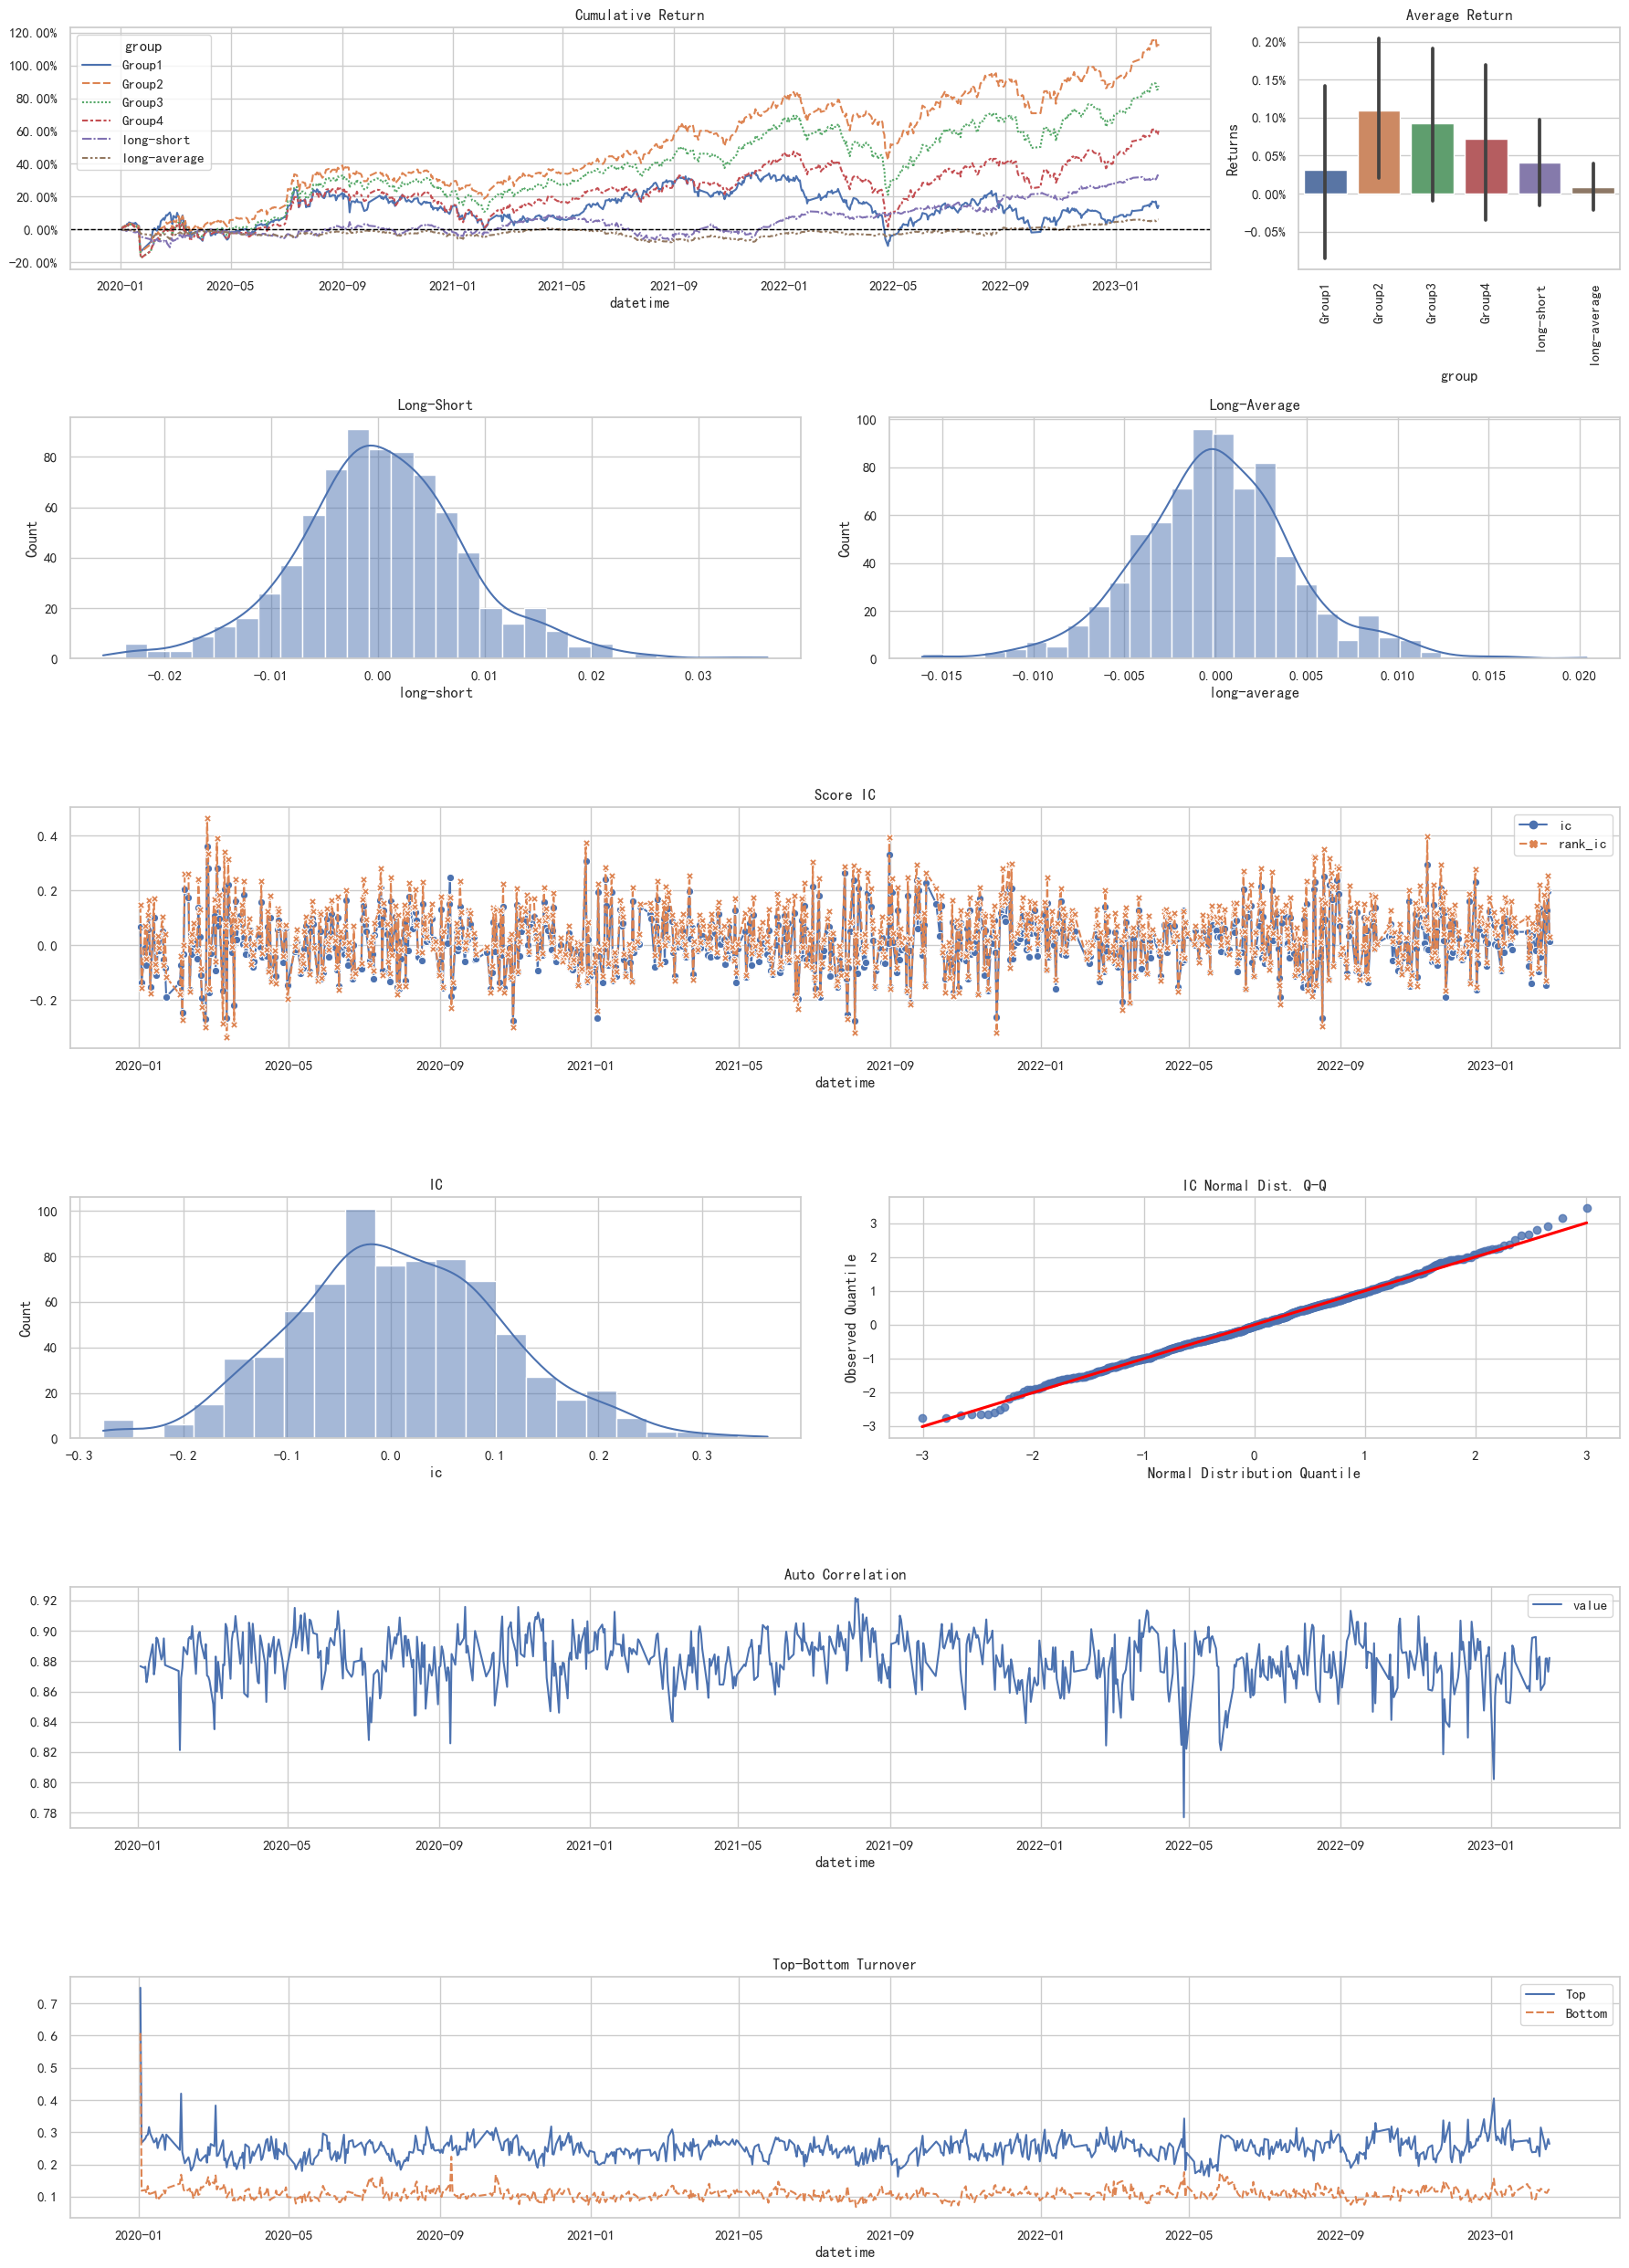

In [44]:
performance_graph = model_performance_graph(pred_label_df,duplicates='drop')

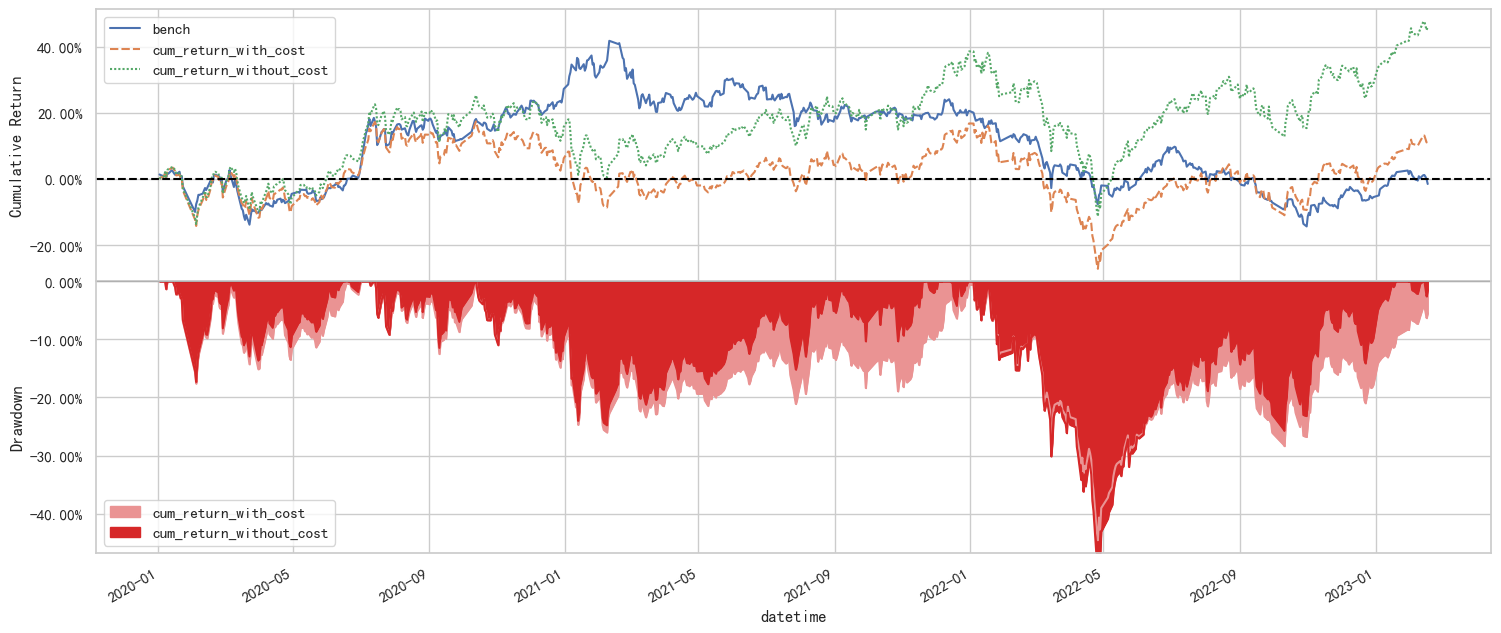

In [45]:
rk_fig = report_graph(lgbmrank_v_model.portfolio_metric_dict['1day'][0])

In [46]:
# 单独回测interday_lowvolatility_momentum因子
score_df: pd.DataFrame = volatility_momentum.loc[
    :, (slice("feature"), slice("interday_lowvolatility_momentum"))
].copy()
score_df.columns = ['score']

In [47]:
lgbmrank_v_model.backtest(
    pred_score=score_df, start_time=TARIN_PERIODS[0], end_time=TEST_PERIODS[1]
)

[9024:MainThread](2023-07-11 16:35:16,785) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x00000259EE0F4AF0>
[9024:MainThread](2023-07-11 16:35:16,790) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[9024:MainThread](2023-07-11 16:35:35,720) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[9024:MainThread](2023-07-11 16:35:35,724) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.


backtest loop:   0%|          | 0/2221 [00:00<?, ?it/s]

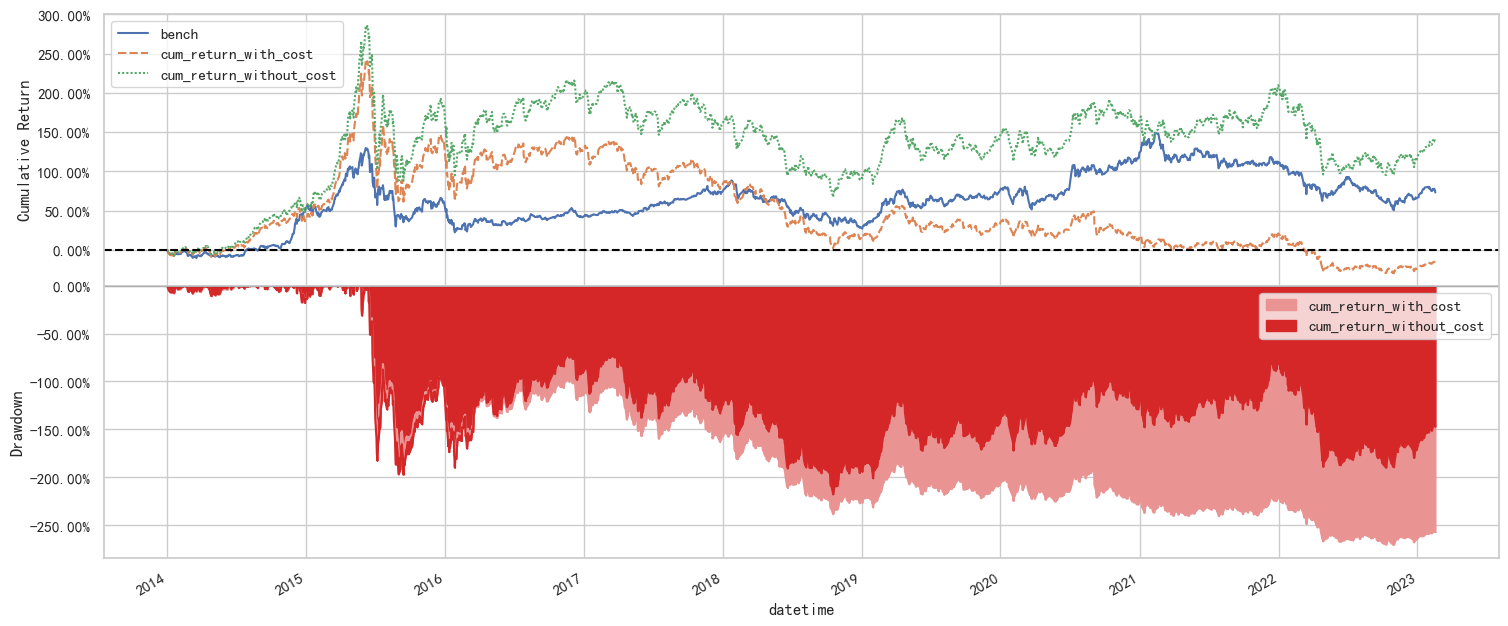

In [48]:
rk_fig = report_graph(lgbmrank_v_model.portfolio_metric_dict["1day"][0])

# 滚动训练

In [15]:
from qlib.workflow import R
from src.rolling import RollingBenchmark

In [16]:
TRAIN_PERIODS: Tuple = ("2014-01-01", "2017-12-31")
VALID_PERIODS: Tuple = ("2018-01-01", "2019-12-31")
TEST_PERIODS: Tuple = ("2020-01-01", "2023-02-17")

In [35]:
rolling_model = RollingBenchmark(
    TRAIN_PERIODS,
    VALID_PERIODS,
    TEST_PERIODS,
    factor_obj=SportBettingsFactor,
    window=20,
    step=20,
    horizon=1,
    exp_name="rolling_test",
    rolling_exp="test",
)
rolling_model.run()

2023-07-19 15:57:30.584 | INFO     | src.build_factor:get_factor_data_and_forward_return:189 - start get base data...
2023-07-19 15:57:50.724 | INFO     | src.build_factor:get_factor_data_and_forward_return:192 - base data success!
2023-07-19 15:57:50.725 | INFO     | src.build_factor:get_factor_data_and_forward_return:194 - start get next return data...
2023-07-19 15:58:12.567 | INFO     | src.build_factor:get_factor_data_and_forward_return:198 - next return data success!
2023-07-19 15:58:12.567 | INFO     | src.build_factor:get_factor_data_and_forward_return:199 - start get factor data...
[Parallel(n_jobs=-1)]: Using backend MultiprocessingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  14 | elapsed:   37.4s remaining:   10.1s
[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed:  1.7min finished
2023-07-19 16:06:00.914 | INFO     | src.build_factor:get_factor_data_and_forward_return:204 - factor data success!
2023-07-19 16:06:00.915 | INFO     | src.build

train tasks:   0%|          | 0/38 [00:00<?, ?it/s]

[27860:MainThread](2023-07-19 16:07:52,216) WARNING - qlib.workflow - [expm.py:230] - No valid experiment found. Create a new experiment with name rolling_models_20230719155730.
[27860:MainThread](2023-07-19 16:07:52,220) INFO - qlib.workflow - [exp.py:258] - Experiment 5 starts running ...
[27860:MainThread](2023-07-19 16:07:52,323) INFO - qlib.workflow - [recorder.py:341] - Recorder 77234b14f9774020ab523d7d374f5972 starts running under Experiment 5 ...


Training until validation scores don't improve for 50 rounds
[20]	train's l2: 0.891413	valid's l2: 0.964208
[40]	train's l2: 0.890785	valid's l2: 0.964216
[60]	train's l2: 0.890116	valid's l2: 0.96432
Early stopping, best iteration is:
[23]	train's l2: 0.891322	valid's l2: 0.964192


[27860:MainThread](2023-07-19 16:07:56,877) INFO - qlib.workflow - [record_temp.py:195] - Signal record 'pred.pkl' has been saved as the artifact of the Experiment 5


...

backtest loop:   0%|          | 0/871 [00:00<?, ?it/s]

d:\anaconda3\envs\qlib_env\lib\site-packages\qlib\utils\index_data.py:481: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
[27860:MainThread](2023-07-19 16:11:25,925) INFO - qlib.workflow - [record_temp.py:504] - Portfolio analysis record 'port_analysis_1day.pkl' has been saved as the artifact of the Experiment 3


'The following are analysis results of benchmark return(1day).'
                       risk
mean               0.000477
std                0.012295
annualized_return  0.113562
information_ratio  0.598699
max_drawdown      -0.370477
'The following are analysis results of the excess return without cost(1day).'
                       risk
mean              -0.000217
std                0.011101
annualized_return -0.051716
information_ratio -0.301979
max_drawdown      -0.400928
'The following are analysis results of the excess return with cost(1day).'
                       risk
mean              -0.000244
std                0.011099
annualized_return -0.058041
information_ratio -0.338961
max_drawdown      -0.404609


[27860:MainThread](2023-07-19 16:11:25,942) INFO - qlib.workflow - [record_temp.py:529] - Indicator analysis record 'indicator_analysis_1day.pkl' has been saved as the artifact of the Experiment 3


'The following are analysis results of indicators(1day).'
     value
ffr    1.0
pa     0.0
pos    0.0
Your evaluation results can be found in the experiment named `None`.


In [37]:
# pred_df: pd.DataFrame = R.get_recorder(
#     experiment_id="3", recorder_id="6210eef4630a4e33814a2c932d8be102"
# ).load_object("pred.pkl")
# label_df: pd.DataFrame = pd.read_pickle("data/pkl/all_data.pkl")[["next_ret"]].rename(
#     columns={"next_ret": "label"}
# )

# pred_label_df: pd.DataFrame = pd.concat((label_df, pred_df), axis=1, sort=True).reindex(
#     pred_df.index
# )

pred_label_df:pd.DataFrame = rolling_model.get_pred(experiment_id='3',recorder_id = '82b88a4264824dbebd747c7e3026cbf8')

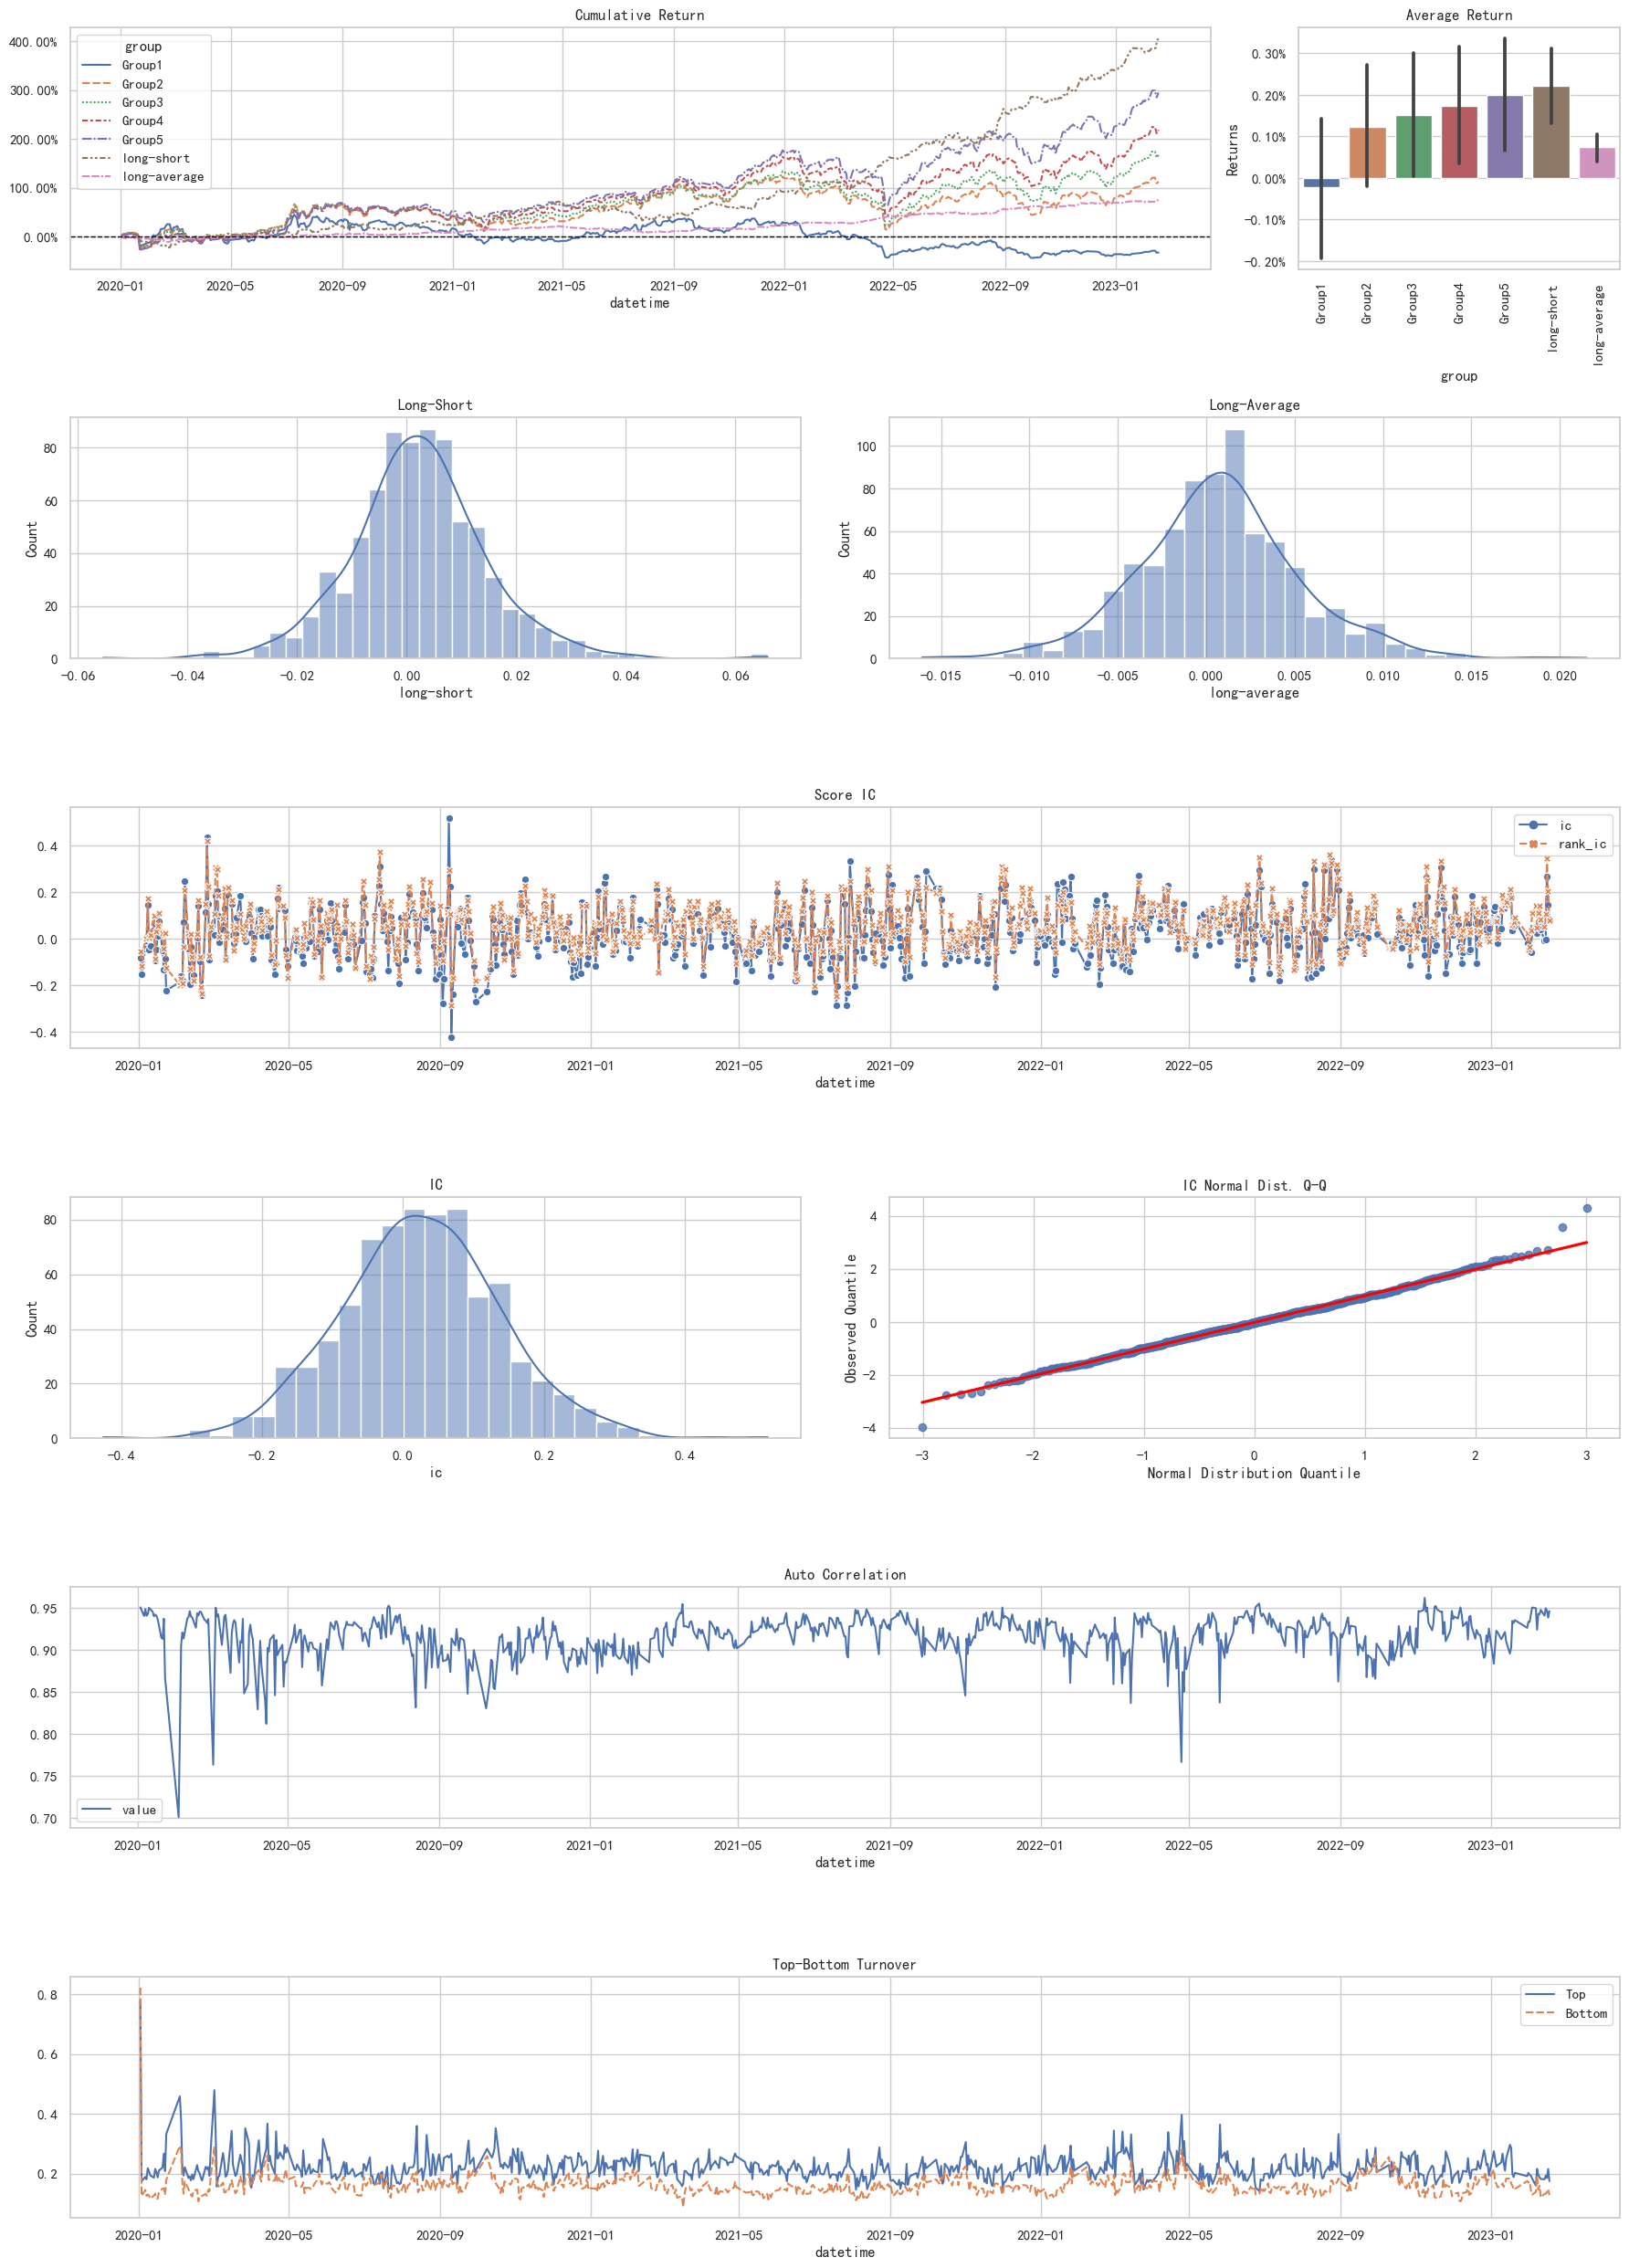

In [38]:
performance_graph = model_performance_graph(pred_label_df)